# Exoplanet Transit Classifier — Training Notebook

This notebook trains a binary classifier to detect exoplanet transits in 201-cadence
Kepler light curve windows. It is the second notebook in this pipeline, operating
entirely on the pre-processed, batched .npz files produced by the Preprocessing notebook.

**Inputs**
- `data/windows/{train,val,test}/batch_NNNNN.npz` — pre-batched windows + labels
- `config.json` — shared pipeline hyperparameters
- `data/processed/star_labels.csv` — star-level label table (used for class weight computation)

**Outputs**
- `models/best_inception_resnet.pt` — best checkpoint (by val recall)
- `models/training_config.json` — full training hyperparameter snapshot
- `logs/training_<timestamp>.log` — full epoch-by-epoch log
- `figures/cnn/` — threshold sweep, confusion matrix, PR curve, ROC, history plots

**Six stages covered**
1. Environment setup — installs, imports, paths, config, seeds, logging
2. Data loading — streaming Dataset for train, in-memory Dataset for val/test,
   DataLoaders, class weight computation, sanity checks
3. Model architecture — InceptionResNet1D with SE block (in_channels=1,
   secondary-eclipse-ready via constructor parameter)
4. Training infrastructure — loss, optimizer, scheduler, early stopping,
   checkpointing, metrics helpers
5. Training loop — per-epoch train/val cycle, logging, best-model checkpointing
6. Evaluation — threshold sweep on val, confusion matrix, PR curve, ROC curve,
   training history plots, and a single final run on the held-out test set

**Important**: Section 8 (test set evaluation) must be run exactly once,
after all hyperparameter decisions are finalised. Running it multiple times
constitutes test set leakage.

## 1. Environment Setup

All required libraries ship pre-installed in Google Colab. This cell re-confirms their presence and pins versions to the log for reproducibility. If you are running this notebook outside Colab, the install commands will install any missing packages.

In [1]:
# Install / verify dependencies
# !pip install -q torch numpy scikit-learn matplotlib seaborn tqdm

All imports are collected here in one place. Nothing is imported later in the notebook.
Keeping imports central makes dependency auditing straightforward.

In [2]:
import bisect
import json
import logging
import math
import random
import time
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, IterableDataset
from sklearn.metrics import (
    auc,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
print("✅ All imports successful.")
print(f"   PyTorch        : {torch.__version__}")
print(f"   CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU            : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ All imports successful.
   PyTorch        : 2.11.0+cu130
   CUDA available : True
   GPU            : NVIDIA GeForce RTX 3070
   VRAM           : 8.2 GB


### Path Configuration

Mirrors the path layout established in the Preprocessing notebook. All paths derive from BASEDIR so that moving the project folder requires changing exactly one line. Every output directory is created here; downstream cells assume they exist.

In [3]:
# ── Root layout (must match Preprocessing notebook) ───────────────────────────
BASEDIR    = Path('/home/USER/PROJECT_ROOT')
DATADIR    = BASEDIR  / 'data'
WINDOWSDIR = DATADIR  / 'windows_plus'       # two-channel (2, 201) windowed dataset
MODELSDIR  = BASEDIR  / 'models' / '2026-04-10 Third Iteration' / 'inception_ResNet'
LOGSDIR    = BASEDIR  / 'logs' / '2026-04-10 Third Iteration' / 'inception_ResNet'
FIGURESDIR = BASEDIR  / 'figures' / '2026-04-10 Third Iteration' / 'inception_ResNet'
PROCESSEDDIR = DATADIR / 'processed'    # star_labels.csv lives here

# ── Split directories ──────────────────────────────────────────────────────────
TRAIN_DIR = WINDOWSDIR / 'train'
VAL_DIR   = WINDOWSDIR / 'val'
TEST_DIR  = WINDOWSDIR / 'test'

# ── Create all output directories ─────────────────────────────────────────────
for d in [MODELSDIR, LOGSDIR, FIGURESDIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Verify input directories exist ────────────────────────────────────────────
for d in [TRAIN_DIR, VAL_DIR, TEST_DIR, PROCESSEDDIR]:
    assert d.exists(), f"Expected directory not found: {d}"

print(f"   BASEDIR    : {BASEDIR}")
print(f"   WINDOWSDIR : {WINDOWSDIR}")
print(f"   MODELSDIR  : {MODELSDIR}")
print(f"   FIGURESDIR : {FIGURESDIR}")

   BASEDIR    : /home/USER/PROJECT_ROOT
   WINDOWSDIR : /home/USER/PROJECT_ROOT/data/windows_plus
   MODELSDIR  : /home/USER/PROJECT_ROOT/models/2026-04-10 Third Iteration/inception_ResNet
   FIGURESDIR : /home/USER/PROJECT_ROOT/figures/2026-04-10 Third Iteration/inception_ResNet


### Configuration & Hyperparameters

All training hyperparameters live in a single dict, TRAIN_CFG. Nothing that controls model behaviour is hardcoded elsewhere in the notebook. This dict is also saved to Drive so that every saved checkpoint has a matching record of the exact settings it was trained with.

Key decisions documented here:
- `in_channels = 2` —  the secondary eclipse view is added
- `pos_weight = 4.2` — intentionally above the natural imbalance ratio (~3.15) to bias the model toward recall. Justified by our false-negative cost asymmetry (a missed transit is lost forever; a false positive is caught by BLS).
- `min_recall = 0.80` — the target recall floor used during threshold selection in Section 6.
- `precision_floor = 0.10` — early stopping aborts if validation precision falls below this, which signals model collapse to all-positive predictions.

In [4]:
# ── Load shared pipeline config (window_length, cadence, etc.) ────────────────
CONFIG_PATH = BASEDIR / 'config.json'
with open(CONFIG_PATH, 'r') as f:
    CONFIG = json.load(f)

print(f"✅ Loaded pipeline config from {CONFIG_PATH}")
print(f"   window_length : {CONFIG['window_length']} cadences")
print(f"   random_seed   : {CONFIG['random_seed']}")

# ── Training hyperparameters ───────────────────────────────────────────────────
TRAIN_CFG = {
    # ── Architecture ──────────────────────────────────────────────────────────
    'in_channels':       2,      # → 2 when secondary eclipse view is added

    # ── Data loading ──────────────────────────────────────────────────────────
    'batch_size':        512,
    'num_workers':       4,

    # ── Optimisation ──────────────────────────────────────────────────────────
    'num_epochs':        80,
    'lr':                5e-6,
    'weight_decay':      1e-4,
    'grad_clip':         1.0,

    # ── Scheduler ──────────────────────────────────────────────────────────
    'pct_start':         0.2,

    # ── Imbalance handling ────────────────────────────────────────────────────
    'pos_weight':        4.2,    # Compared against computed value in Cell 2.2

    # ── Regularisation ────────────────────────────────────────────────────────
    'dropout':           0.3,

    # ── Early stopping ────────────────────────────────────────────────────────
    'patience':          20,
    'warmup_epochs':     16,   # No ES penalty during warmup; num_epochs * pct_start
    'precision_floor':   0.20,   # Guard against all-positive collapse

    # ── Threshold selection (Section 6) ───────────────────────────────────────
    'min_recall':        0.85,   # Find threshold with recall ≥ this, max precision

    # ── Reproducibility ───────────────────────────────────────────────────────
    'random_seed':       CONFIG['random_seed'],  # Inherit from pipeline config
}

# ── Checkpoint path (defined once, referenced everywhere) ─────────────────────
BEST_CKPT_PATH        = MODELSDIR / 'best_auc_inception_resnet.pt'
BEST_RECALL_CKPT_PATH = MODELSDIR / 'best_recall_inception_resnet.pt'
BEST_F1_CKPT_PATH     = MODELSDIR / 'best_f1_inception_resnet.pt'
EPOCH_CKPTS_DIR       = MODELSDIR / 'epoch_checkpoints'
EPOCH_CKPTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Persist training config alongside the checkpoint ──────────────────────────
train_cfg_path = MODELSDIR / 'training_config.json'
with open(train_cfg_path, 'w') as f:
    json.dump(TRAIN_CFG, f, indent=2)

print(f"\n✅ Training config saved to {train_cfg_path}")
print(f"\n{'─'*45}")
print(f"  TRAIN_CFG summary")
print(f"{'─'*45}")
for k, v in TRAIN_CFG.items():
    print(f"  {k:<22}: {v}")
print(f"{'─'*45}")

✅ Loaded pipeline config from /home/USER/PROJECT_ROOT/config.json
   window_length : 201 cadences
   random_seed   : 42

✅ Training config saved to /home/USER/PROJECT_ROOT/models/2026-04-10 Third Iteration/inception_ResNet/training_config.json

─────────────────────────────────────────────
  TRAIN_CFG summary
─────────────────────────────────────────────
  in_channels           : 2
  batch_size            : 512
  num_workers           : 4
  num_epochs            : 80
  lr                    : 5e-06
  weight_decay          : 0.0001
  grad_clip             : 1.0
  pct_start             : 0.2
  pos_weight            : 4.2
  dropout               : 0.3
  patience              : 20
  warmup_epochs         : 16
  precision_floor       : 0.2
  min_recall            : 0.85
  random_seed           : 42
─────────────────────────────────────────────


### Reproducibility & Device Setup

All random number generators are seeded identically so that two runs from this cell produce the same model. `torch.backends.cudnn.deterministic = True` is set for full determinism at a small runtime cost (~2–5%). On a T4 this is acceptable.

The cell also asserts that a CUDA GPU is available. If this assertion fails, the session has no GPU attached — go to Runtime → Change runtime type → GPU.

In [5]:
def set_all_seeds(seed: int) -> None:
    """Seed every RNG that PyTorch, NumPy, or Python might use."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False  # Disable auto-tuning for full reproducibility

set_all_seeds(TRAIN_CFG['random_seed'])

# ── Device detection ──────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert device.type == 'cuda', (
    "No GPU detected. Go to Runtime → Change runtime type → Hardware accelerator → GPU."
)

print(f"✅ Random seeds set (seed={TRAIN_CFG['random_seed']})")
print(f"✅ Device : {device} ({torch.cuda.get_device_name(0)})")
print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"   CUDA   : {torch.version.cuda}")

✅ Random seeds set (seed=42)
✅ Device : cuda (NVIDIA GeForce RTX 3070)
   VRAM   : 8.21 GB
   CUDA   : 13.0


### Logging Setup

Every significant event during training — metrics, checkpoint saves, early stopping triggers, warnings — is written to a timestamped log file on Drive.
This mirrors the Preprocessing notebook's logging pattern. If the Colab session crashes mid-training, the log file on Drive preserves the full training history up to that point.

Log level INFO is written to file; WARNING and above are echoed to the console.

In [6]:
# ── Timestamped log file ──────────────────────────────────────────────────────
ts      = datetime.now().strftime('%Y-%m-%d_%H%M%S')
logfile = LOGSDIR / f'training_{ts}.log'

# Reset root logger (important if cell is re-run in the same session)
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    level    = logging.INFO,
    format   = '%(asctime)s  %(levelname)-8s  %(message)s',
    datefmt  = '%H:%M:%S',
    handlers = [
        logging.FileHandler(logfile),
        logging.StreamHandler(),           # Console: WARNING+ only
    ],
)
# Suppress console below WARNING to keep output clean during training
logging.getLogger().handlers[1].setLevel(logging.WARNING)

log = logging.getLogger('exoplanet_cnn')
log.info('='*60)
log.info('Exoplanet Transit Classifier — Training Run')
log.info(f'Timestamp  : {ts}')
log.info(f'Log file   : {logfile}')
log.info(f'Device     : {device} ({torch.cuda.get_device_name(0)})')
log.info(f'Seed       : {TRAIN_CFG["random_seed"]}')
log.info('TRAIN_CFG  : ' + json.dumps(TRAIN_CFG))
log.info('='*60)

print(f"✅ Logging active.")
print(f"   Log file : {logfile}")

✅ Logging active.
   Log file : /home/USER/PROJECT_ROOT/logs/2026-04-10 Third Iteration/inception_ResNet/training_2026-04-11_095339.log


## 2. Data Loading

This section builds the complete data pipeline in five steps:

1. **Data audit** — Loads one batch from each split to verify shapes, dtypes, NaN counts, and label distributions against expected values. Any mismatch here stops execution before any GPU time is wasted.

2. **Class weight computation** — Scans all training files to count exact positive/negative windows after augmentation. Produces `pos_weight` for the loss function and an initial `steps_per_epoch` estimate.

3. **Dataset and DataLoader construction** — `NpzBatchStreamingDataset` streams training data as pre-assembled batches; `NpzInMemoryDataset` loads val and test fully into RAM (both fit). Three DataLoaders are constructed and `steps_per_epoch` is refined by scanning actual file sizes.

4. **Sanity checks** — Pulls one batch from each loader and asserts shape, dtype, value range, and label presence.

In [7]:
def inspect_split(split_dir: Path, split_name: str) -> None:
    """Load the first batch file from a split and print a diagnostic summary."""
    files = sorted(split_dir.glob('batch_*.npz'))
    assert len(files) > 0, f"No batch_*.npz files found in {split_dir}"

    sample = np.load(files[0], allow_pickle=False)
    windows = sample['windows']
    labels  = sample['labels']

    n_pos   = int((labels == 1).sum())
    n_neg   = int((labels == 0).sum())
    n_total = len(labels)

    print(f"\n{'─'*50}")
    print(f"  Split      : {split_name}")
    print(f"  # files    : {len(files)}")
    print(f"  Sample file: {files[0].name}")
    print(f"  windows    : shape={windows.shape}, dtype={windows.dtype}")
    print(f"  labels     : shape={labels.shape},  dtype={labels.dtype}")
    print(f"  Label dist : {n_pos}/{n_total} positive ({100*n_pos/n_total:.1f}%)")
    print(f"  Flux stats : min={windows.min():.4f}  max={windows.max():.4f}"
          f"  mean={windows.mean():.4f}  std={windows.std():.4f}")

    nan_count = int(np.isnan(windows).sum())
    inf_count = int(np.isinf(windows).sum())
    print(f"  NaN count  : {nan_count}  ({'⚠️  INVESTIGATE' if nan_count > 0 else '✅ clean'})")
    print(f"  Inf count  : {inf_count}  ({'⚠️  INVESTIGATE' if inf_count > 0 else '✅ clean'})")
    print(f"{'─'*50}")

    log.info(f"Split {split_name}: {len(files)} files, sample shape {windows.shape}, "
             f"{100*n_pos/n_total:.1f}% positive")

inspect_split(TRAIN_DIR, 'train')
inspect_split(VAL_DIR,   'val')
inspect_split(TEST_DIR,  'test')


──────────────────────────────────────────────────
  Split      : train
  # files    : 47
  Sample file: batch_00000.npz
  windows    : shape=(254425, 2, 201), dtype=float32
  labels     : shape=(254425,),  dtype=int8
  Label dist : 67329/254425 positive (26.5%)
  Flux stats : min=0.7027  max=1.2208  mean=0.9998  std=0.0056
  NaN count  : 0  (✅ clean)
  Inf count  : 0  (✅ clean)
──────────────────────────────────────────────────

──────────────────────────────────────────────────
  Split      : val
  # files    : 10
  Sample file: batch_00000.npz
  windows    : shape=(112396, 2, 201), dtype=float32
  labels     : shape=(112396,),  dtype=int8
  Label dist : 20661/112396 positive (18.4%)
  Flux stats : min=-0.4294  max=1.8338  mean=0.9995  std=0.0164
  NaN count  : 0  (✅ clean)
  Inf count  : 0  (✅ clean)
──────────────────────────────────────────────────

──────────────────────────────────────────────────
  Split      : test
  # files    : 10
  Sample file: batch_00000.npz
  windows   

### Class Weight Computation

We scan every training batch file to obtain the exact count of positive and negative windows after augmentation. This gives us two numbers:

- `natural_pos_weight = n_neg / n_pos`  — the actuarially fair weight that makes BCE loss treat both classes equally in expectation.
- `TRAIN_CFG['pos_weight']` (default 3.2 _changed from 5.0_) — intentionally elevated above the natural value to bias the model toward recall, consistent with our false-negative cost asymmetry.

Both values are printed and logged. If the computed natural weight differs substantially from what was expected (~3.1), it indicates the augmentation strategy changed and TRAIN_CFG['pos_weight'] may need re-tuning.

This cell also computes `n_train_windows`, which is needed to set
`steps_per_epoch` for the OneCycleLR scheduler in Section 4.

This cell also computes an **initial estimate** of `steps_per_epoch = math.ceil(total_windows / batch_size)`. This estimate uses `math.ceil` and does not account for the per-file drop-last behaviour inside `NpzBatchStreamingDataset`. The exact value is recomputed in Cell 2.4b by scanning actual file sizes and is what gets passed to `OneCycleLR`. The estimate here is printed for reference only.

In [8]:
print("Scanning training batch files for class distribution...")
print("(This reads file headers only — fast even for 1000+ files)\n")

n_pos_train   = 0
n_neg_train   = 0
train_files   = sorted(TRAIN_DIR.glob('batch_*.npz'))

for fpath in tqdm(train_files, desc='Counting labels', unit='file'):
    d = np.load(fpath, allow_pickle=False)
    lbl = d['labels']
    n_pos_train += int((lbl == 1).sum())
    n_neg_train += int((lbl == 0).sum())

n_train_windows    = n_pos_train + n_neg_train
natural_pos_weight = n_neg_train / n_pos_train
pos_frac_train     = n_pos_train / n_train_windows

# ── Steps per epoch (needed for OneCycleLR in Section 4) ──────────────────────
steps_per_epoch = math.ceil(n_train_windows / TRAIN_CFG['batch_size'])

print(f"\n{'─'*50}")
print(f"  Training set statistics")
print(f"{'─'*50}")
print(f"  Total windows     : {n_train_windows:>12,}")
print(f"  Positive (label=1): {n_pos_train:>12,}  ({100*pos_frac_train:.1f}%)")
print(f"  Negative (label=0): {n_neg_train:>12,}  ({100*(1-pos_frac_train):.1f}%)")
print(f"{'─'*50}")
print(f"  Natural pos_weight: {natural_pos_weight:.2f}  (n_neg / n_pos)")
print(f"  TRAIN_CFG pos_weight (used): {TRAIN_CFG['pos_weight']:.2f}")

if TRAIN_CFG['pos_weight'] < natural_pos_weight:
    print(f"\n  ⚠️  WARNING: TRAIN_CFG['pos_weight'] ({TRAIN_CFG['pos_weight']}) is BELOW "
          f"the natural ratio ({natural_pos_weight:.2f}).")
    print(f"     This under-weights the positive class. Consider raising pos_weight.")
elif TRAIN_CFG['pos_weight'] > 3 * natural_pos_weight:
    print(f"\n  ⚠️  WARNING: TRAIN_CFG['pos_weight'] ({TRAIN_CFG['pos_weight']}) is >3× "
          f"the natural ratio ({natural_pos_weight:.2f}).")
    print(f"     Monitor val precision — risk of all-positive collapse.")
else:
    print(f"\n  ✅ pos_weight is moderately elevated above natural ratio "
          f"(+{100*(TRAIN_CFG['pos_weight']/natural_pos_weight - 1):.0f}%). "
          f"Appropriate for recall-biased training.")

print(f"\n  Steps per epoch   : {steps_per_epoch:>12,}  (at batch_size={TRAIN_CFG['batch_size']})")
print(f"{'─'*50}")

log.info(f"Train: {n_train_windows:,} windows | pos={n_pos_train:,} ({100*pos_frac_train:.1f}%) | "
         f"neg={n_neg_train:,} | natural_pos_weight={natural_pos_weight:.3f} | "
         f"used_pos_weight={TRAIN_CFG['pos_weight']} | steps_per_epoch={steps_per_epoch}")

Scanning training batch files for class distribution...
(This reads file headers only — fast even for 1000+ files)



Counting labels:   0%|          | 0/47 [00:00<?, ?file/s]


──────────────────────────────────────────────────
  Training set statistics
──────────────────────────────────────────────────
  Total windows     :   11,791,812
  Positive (label=1):    2,838,720  (24.1%)
  Negative (label=0):    8,953,092  (75.9%)
──────────────────────────────────────────────────
  Natural pos_weight: 3.15  (n_neg / n_pos)
  TRAIN_CFG pos_weight (used): 4.20

  ✅ pos_weight is moderately elevated above natural ratio (+33%). Appropriate for recall-biased training.

  Steps per epoch   :       23,031  (at batch_size=512)
──────────────────────────────────────────────────


### Dataset Classes

**NpzInMemoryDataset** (Dataset) — for the validation and test sets. Val (0.93 GB) and test (0.94 GB) both fit comfortably in RAM. Loading them once at the start of training avoids repeated Drive I/O during the validation loop, which would dominate epoch time otherwise. The full arrays are stored as pre-allocated PyTorch tensors for fast random-access indexing.

Note on shuffle: the DataLoader `shuffle` parameter only applies to map-style Datasets. For NpzStreamingDataset, shuffling is handled internally and the DataLoader must be created with `shuffle=False`.

In [9]:
class NpzInMemoryDataset(Dataset):
    """
    In-memory dataset for the validation and test splits.

    All batch files are concatenated into a single pre-allocated tensor at
    construction time. __getitem__ is then an O(1) tensor index — no file I/O
    during training.

    Parameters
    ----------
    split_dir   : Path to the directory containing batch_*.npz files.
    in_channels : Passed through for API consistency; currently unused (always 1).
    """
    def __init__(self, split_dir: Path, in_channels: int = 1):
        files = sorted(split_dir.glob('batch_*.npz'))
        if len(files) == 0:
            raise FileNotFoundError(f"No batch_*.npz files found in {split_dir}")

        chunks_w, chunks_l = [], []
        for f in tqdm(files, desc=f'  Loading {split_dir.name}', leave=False):
            d = np.load(f, allow_pickle=False)
            chunks_w.append(d['windows'].astype(np.float32))
            chunks_l.append(d['labels'].astype(np.float32))

        windows = np.concatenate(chunks_w, axis=0)   # (N, 2, 201)
        labels  = np.concatenate(chunks_l, axis=0)   # (N,)

        # Store as contiguous tensors: (N, 2, 201) and (N,)
        self.windows = torch.from_numpy(windows)
        self.labels  = torch.from_numpy(labels)

        # Shuffle once at load time so batches have representative class mix
        idx = torch.randperm(len(self.labels))
        self.windows = self.windows[idx]
        self.labels  = self.labels[idx]

        n_pos = int((labels == 1).sum())
        log.info(f"Loaded {split_dir.name}: {len(labels):,} windows, "
                 f"{100*n_pos/len(labels):.1f}% positive, "
                 f"RAM ~{self.windows.nbytes / 1e9:.2f} GB")

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int):
        return self.windows[idx], self.labels[idx]




print("✅ NpzStreamingDataset and NpzInMemoryDataset defined.")

✅ NpzStreamingDataset and NpzInMemoryDataset defined.


### DataLoader Construction

Val and test DataLoaders are constructed here from the in-memory datasets. The train DataLoader is built in the next cell using `NpzBatchStreamingDataset`, which is why only two loaders appear here.

Key settings:

- `num_workers=4`
- `pin_memory=True`: Even with `num_workers=0`, pinning tensors in page-locked host memory enables asynchronous GPU transfer via `cudaMemcpyAsync`, giving ~10–15% throughput gain on T4.
- Val and test use `shuffle=False` to ensure consistent example ordering across evaluation runs, which matters when comparing logits across checkpoints.

Val and test datasets are loaded fully into RAM here. This takes ~30–60 seconds on the first run. All validation passes throughout training use these in-memory copies — no Drive I/O after this point.

Note: `steps_per_epoch` printed here is an estimate from Cell 2.2 (`math.ceil`). The exact value, accounting for drop-last-within-file behaviour, is computed in Cell 2.4b and used for the OneCycleLR scheduler.

In [10]:
# ── Instantiate in-memory datasets (val + test) ────────────────────────────────
print("Instantiating val and test datasets...")

print("\n  Loading validation dataset into RAM...")
val_dataset = NpzInMemoryDataset(
    split_dir   = VAL_DIR,
    in_channels = TRAIN_CFG['in_channels'],
)
print(f"  ✅ Val  : {len(val_dataset):,} windows loaded.")

print("\n  Loading test dataset into RAM...")
test_dataset = NpzInMemoryDataset(
    split_dir   = TEST_DIR,
    in_channels = TRAIN_CFG['in_channels'],
)
print(f"  ✅ Test : {len(test_dataset):,} windows loaded.")

# ── Shared DataLoader kwargs ───────────────────────────────────────────────────
_loader_kwargs = dict(
    batch_size  = TRAIN_CFG['batch_size'],
    num_workers = 0,
    pin_memory  = True,
)

val_loader = DataLoader(
    val_dataset,
    shuffle   = False,
    drop_last = False,
    **_loader_kwargs,
)

test_loader = DataLoader(
    test_dataset,
    shuffle   = False,
    drop_last = False,
    **_loader_kwargs,
)

# ── Summary ────────────────────────────────────────────────────────────────────
n_val_windows        = len(val_dataset)
n_test_windows       = len(test_dataset)
val_steps_per_epoch  = math.floor(n_val_windows  / TRAIN_CFG['batch_size'])
test_steps_per_epoch = math.floor(n_test_windows / TRAIN_CFG['batch_size'])

print(f"\n{'─'*50}")
print(f"  Val  DataLoader : {len(val_loader):,} batches  ({n_val_windows:,} windows)")
print(f"  Test DataLoader : {len(test_loader):,} batches  ({n_test_windows:,} windows)")
print(f"  Train steps/epoch (estimate): {steps_per_epoch:,}  — refined in next cell")
print(f"{'─'*50}")

log.info(f"Val/test DataLoaders created | val_batches={len(val_loader)} | test_batches={len(test_loader)}")

Instantiating val and test datasets...

  Loading validation dataset into RAM...


  Loading val:   0%|          | 0/10 [00:00<?, ?it/s]

  ✅ Val  : 1,160,105 windows loaded.

  Loading test dataset into RAM...


  Loading test:   0%|          | 0/10 [00:00<?, ?it/s]

  ✅ Test : 1,161,306 windows loaded.

──────────────────────────────────────────────────
  Val  DataLoader : 2,266 batches  (1,160,105 windows)
  Test DataLoader : 2,269 batches  (1,161,306 windows)
  Train steps/epoch (estimate): 23,031  — refined in next cell
──────────────────────────────────────────────────


### NpzBatchStreamingDataset

Replaces NpzStreamingDataset. Instead of yielding one (window, label) pair
per __iter__ call and relying on the DataLoader to collate 512 of them,
this dataset yields pre-assembled batches of shape (B, 1, 201) directly.

The DataLoader is constructed with batch_size=1 and collate_fn=lambda x: x[0]
(identity collation) so it passes the pre-assembled batch through untouched.

Why this is faster:
  Old: 512 Python yield calls + tensor allocation per batch → ~425ms
  New: 1 numpy slice + torch.from_numpy per batch          → ~5-10ms

The shuffling logic is preserved: files are shuffled each epoch, and
windows within each file are shuffled before batching.

In [11]:
class NpzBatchStreamingDataset(IterableDataset):
    """
    Streaming dataset that yields pre-assembled (B, 1, 201) batches directly,
    bypassing DataLoader collation overhead entirely.

    Each .npz file contains a pre-batched array of windows and labels.
    __iter__ groups them into chunks of batch_size and yields each chunk as
    a (torch.FloatTensor, torch.FloatTensor) pair ready for the model.

    Parameters
    ----------
    split_dir  : Directory containing batch_*.npz files.
    batch_size : Number of windows per yielded batch.
    shuffle    : If True, shuffle file order and within-file window order.
    """
    def __init__(self, split_dir: Path, batch_size: int, shuffle: bool = True):
        self.files      = sorted(split_dir.glob('batch_*.npz'))
        self.batch_size = batch_size
        self.shuffle    = shuffle

        if len(self.files) == 0:
            raise FileNotFoundError(
                f"No batch_*.npz files found in {split_dir}"
            )

    def __iter__(self):
        files = list(self.files)

        # ── Worker partitioning MUST happen before shuffle ────────────────────
        # Each worker gets a disjoint slice of files. Without this, every
        # worker iterates all files → steps-per-epoch inflated by num_workers.
        worker_info = torch.utils.data.get_worker_info()
        if worker_info is not None:
            files = files[worker_info.id :: worker_info.num_workers]

        # Shuffle each worker's own slice independently
        if self.shuffle:
            random.shuffle(files)

        for fpath in files:
            d       = np.load(fpath, allow_pickle=False)
            windows = d['windows']  # (N, 1, 201)  float32
            labels  = d['labels']   # (N,)          float32

            # Optionally shuffle windows within this file
            if self.shuffle:
                idx = np.random.permutation(len(labels))
                windows = windows[idx]
                labels  = labels[idx]

            # Yield pre-assembled batches of batch_size
            # The DataLoader sees batch_size=1 and identity_collate passes
            # each yielded tensor pair straight through unchanged.
            for start in range(0, len(labels), self.batch_size):
                end = start + self.batch_size
                x = torch.from_numpy(windows[start:end]).float() # (B, 2, 201)
                y = torch.from_numpy(labels[start:end]).float()   # (B,)
                yield x, y


def identity_collate(batch):
    """
    Pass pre-assembled (x, y) tensor pairs straight through.
    batch is a list of length 1 — the single item yielded by __iter__.
    Returns (x, y) directly; no stacking or copying.
    """
    return batch[0]


# ── Build train DataLoader ────────────────────────────────────────────────────
train_dataset = NpzBatchStreamingDataset(
    split_dir  = TRAIN_DIR,
    batch_size = TRAIN_CFG['batch_size'],
    shuffle    = True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = 1,               # dataset already yields full batches
    num_workers = TRAIN_CFG['num_workers'],
    pin_memory  = True,
    collate_fn  = identity_collate,
    drop_last   = False,
    persistent_workers = True
)

print("✅ NpzBatchStreamingDataset constructed.")
print(f"   Batch size : {TRAIN_CFG['batch_size']}")
print(f"   Files      : {len(train_dataset.files)}")

# ── Recompute steps_per_epoch ─────────────────────────────────────────────────
# Count how many full + partial batches each file contributes.
# Using len(labels) without floor division to count the last partial batch too,
# which the dataset yields (drop_last=False, slicing handles the tail).
print("\n   Scanning to recompute steps_per_epoch ...")
steps_per_epoch = 0
for fpath in tqdm(train_dataset.files, desc='  Scanning', leave=False):
    d = np.load(fpath, allow_pickle=False)
    n = len(d['labels'])
    steps_per_epoch += math.ceil(n / TRAIN_CFG['batch_size'])

print(f"   steps_per_epoch : {steps_per_epoch:,}")
log.info(f"NpzBatchStreamingDataset: steps_per_epoch={steps_per_epoch}")

✅ NpzBatchStreamingDataset constructed.
   Batch size : 512
   Files      : 47

   Scanning to recompute steps_per_epoch ...


  Scanning:   0%|          | 0/47 [00:00<?, ?it/s]

   steps_per_epoch : 23,054


### DataLoader Sanity Check

Pull one batch from each DataLoader and verify:
1. Shapes are (B, 1, 201) for windows and (B,) for labels — the exact format the model expects.
2. No NaN or Inf values have survived preprocessing (a second line of defence after the single-file check in Cell 2.1).
3. Flux values are centred near 1.0 with small spread — confirming no double-normalisation occurred.
4. Both label classes are present in the sampled batch. If the batch contains only negatives, it is not necessarily a bug (small chance with 18–24% positives), but it warrants a note.

A failed assertion here stops training before any GPU time is spent.

In [12]:
def sanity_check_loader(loader, name: str) -> None:
    """Pull one batch and assert expected properties."""
    x_batch, y_batch = next(iter(loader))

    expected_window = CONFIG['window_length']
    expected_channels = TRAIN_CFG['in_channels']

    # ── Shape checks ──────────────────────────────────────────────────────────
    assert x_batch.ndim == 3, \
        f"[{name}] Expected 3D tensor (B, C, T), got {x_batch.shape}"
    assert x_batch.shape[1] == expected_channels, \
        f"[{name}] Expected {expected_channels} channels, got {x_batch.shape[1]}"
    assert x_batch.shape[2] == expected_window, \
        f"[{name}] Expected window length {expected_window}, got {x_batch.shape[2]}"
    assert y_batch.ndim == 1, \
        f"[{name}] Expected 1D label tensor, got {y_batch.shape}"

    # ── Value checks ──────────────────────────────────────────────────────────
    assert not torch.isnan(x_batch).any(), f"[{name}] NaN detected in windows!"
    assert not torch.isinf(x_batch).any(), f"[{name}] Inf detected in windows!"

    flux_mean = x_batch.mean().item()
    flux_std  = x_batch.std().item()
    assert 0.5 < flux_mean < 1.5, \
        f"[{name}] Flux mean={flux_mean:.4f} is far from 1.0 — possible double-normalisation."

    # ── Label check ───────────────────────────────────────────────────────────
    n_pos_batch = (y_batch == 1).sum().item()
    n_neg_batch = (y_batch == 0).sum().item()

    unique_labels = y_batch.unique().tolist()
    label_warning = ""
    if 1.0 not in unique_labels:
        label_warning = "  ⚠️  No positive examples in this batch (possible with low-pos split)."

    print(f"\n  ✅ [{name}]")
    print(f"     x shape   : {tuple(x_batch.shape)}  (B, C, T)")
    print(f"     y shape   : {tuple(y_batch.shape)}")
    print(f"     flux mean : {flux_mean:.5f}   std : {flux_std:.5f}")
    print(f"     flux range: [{x_batch.min():.4f}, {x_batch.max():.4f}]")
    if x_batch.shape[1] == 2:
        print(f"     ch0 mean  : {x_batch[:,0,:].mean():.5f}   std : {x_batch[:,0,:].std():.5f}  (primary)")
        print(f"     ch1 mean  : {x_batch[:,1,:].mean():.5f}   std : {x_batch[:,1,:].std():.5f}  (secondary)")
    print(f"     positives : {n_pos_batch}/{len(y_batch)}  ({100*n_pos_batch/len(y_batch):.1f}%)")
    if label_warning:
        print(label_warning)

print("Running DataLoader sanity checks...\n")
sanity_check_loader(train_loader, 'train_loader')
sanity_check_loader(val_loader,   'val_loader')
sanity_check_loader(test_loader,  'test_loader')

print(f"\n{'─'*50}")
print("  ✅ All sanity checks passed. Data pipeline is clean.")
print("     Proceed to Section 3 — Model Architecture.")
print(f"{'─'*50}")

log.info("Data pipeline sanity checks passed.")

Running DataLoader sanity checks...


  ✅ [train_loader]
     x shape   : (512, 2, 201)  (B, C, T)
     y shape   : (512,)
     flux mean : 0.99971   std : 0.00820
     flux range: [0.6866, 1.0519]
     ch0 mean  : 0.99942   std : 0.01157  (primary)
     ch1 mean  : 1.00000   std : 0.00072  (secondary)
     positives : 99/512  (19.3%)

  ✅ [val_loader]
     x shape   : (512, 2, 201)  (B, C, T)
     y shape   : (512,)
     flux mean : 0.99947   std : 0.01136
     flux range: [0.5236, 1.1159]
     ch0 mean  : 0.99892   std : 0.01602  (primary)
     ch1 mean  : 1.00001   std : 0.00097  (secondary)
     positives : 111/512  (21.7%)

  ✅ [test_loader]
     x shape   : (512, 2, 201)  (B, C, T)
     y shape   : (512,)
     flux mean : 0.99939   std : 0.01389
     flux range: [0.0839, 1.3513]
     ch0 mean  : 0.99878   std : 0.01962  (primary)
     ch1 mean  : 1.00000   std : 0.00052  (secondary)
     positives : 83/512  (16.2%)

──────────────────────────────────────────────────
  ✅ All sanit

## 3. Model Architecture

The classifier is an InceptionResNet1D — a 1D convolutional network that combines two ideas:

**InceptionTime-style multi-scale convolutions**
Each Inception module reads its input through four parallel branches simultaneously:
kernel sizes 3, 7, and 15 operating on a bottlenecked input, plus a MaxPool branch on the raw input. The three kernel sizes are not arbitrary — they correspond directly to the transit durations we expect to see at 29.4-minute Kepler cadence:

  k=3  →  ~1.5 hrs  (ingress/egress edges of most transits)
  k=7  →  ~3.4 hrs  (typical hot Jupiter transit duration)
  k=15 →  ~7.4 hrs  (long-period, slow transits)

Running all three in parallel means the network sees every transit scale at every layer, not just after accumulating enough depth for the receptive field to grow.

**Residual connections**
Transit signals are small (100–10,000 ppm on a baseline of ~1.0). Without skip connections, deep networks suppress small deviations in early layers. Residuals ensure the raw flux perturbation propagates to the classification head intact.

**Squeeze-and-Excitation (SE) block**
After the final Inception module, an SE block learns to reweight all 256 feature channels: "for this window, how important is each learned feature?" This is cheap (~8K parameters) and consistently improves performance on multi-scale feature sets.

**Global Average Pooling (GAP)**
Instead of flattening, GAP averages each feature channel over the time axis. This makes the model invariant to small positional shifts of the transit within the 201-cadence window — which is physically correct, since the transit can be centred anywhere in the window.

**Secondary-view ready**
The constructor takes `in_channels` as a parameter (default 1). When the secondary eclipse view is added, only `in_channels=2` needs to change. All other weights transfer from the single-view checkpoint with a one-time stem weight surgery.

### The InceptionBlock

The atomic building block of the network. Each block:
1. Compresses the input to `bottleneck_size` channels via a 1×1 conv (reduces computation in the parallel branches without losing information).
2. Runs three parallel Conv1d branches at k=3, k=7, k=15 on the bottleneck output.
3. Runs a MaxPool branch directly on the original (pre-bottleneck) input and projects it to `nb_filters` channels via a 1×1 conv.
4. Concatenates all four branch outputs: shape (B, nb_filters*4, T).
5. Applies BatchNorm + GELU.
6. Adds a residual shortcut from input to output. If input and output channel counts differ (which they do on the first call), the shortcut is a 1×1 conv followed by BN. Otherwise it is a plain BN on the identity path.

The output is always (B, nb_filters*4, T) — the time dimension T is unchanged.
Downsampling between blocks is handled by explicit MaxPool layers in the trunk, not inside the InceptionBlock itself. This keeps the block reusable.

In [13]:
class InceptionBlock(nn.Module):
    """
    One InceptionTime-style module with four parallel branches and a residual shortcut.

    Parameters
    ----------
    in_channels     : Number of input channels.
    nb_filters      : Number of filters per branch. Output channels = nb_filters * 4.
    bottleneck_size : Width of the 1×1 bottleneck applied before the parallel convs.
    """
    def __init__(self, in_channels: int, nb_filters: int = 32, bottleneck_size: int = 32):
        super().__init__()

        self.bottleneck = nn.Conv1d(
            in_channels, bottleneck_size, kernel_size=1, bias=False
        )

        # Three parallel convolutions on the bottleneck output
        self.conv_k3  = nn.Conv1d(bottleneck_size, nb_filters, kernel_size=3,  padding=1,  bias=False)
        self.conv_k7  = nn.Conv1d(bottleneck_size, nb_filters, kernel_size=7,  padding=3,  bias=False)
        self.conv_k15 = nn.Conv1d(bottleneck_size, nb_filters, kernel_size=15, padding=7,  bias=False)

        # MaxPool branch — operates on raw input before bottleneck
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=1, padding=1)
        self.conv_mp = nn.Conv1d(in_channels, nb_filters, kernel_size=1, bias=False)

        # Post-concat normalisation + activation
        out_channels = nb_filters * 4
        self.bn  = nn.BatchNorm1d(out_channels)
        self.act = nn.GELU()

        # Residual shortcut: project if channel count changes, else plain BN
        if in_channels == out_channels:
            self.shortcut = nn.Identity()
        else:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.shortcut(x)

        b_out = self.bottleneck(x)

        b1 = self.conv_k3(b_out)
        b2 = self.conv_k7(b_out)
        b3 = self.conv_k15(b_out)
        b4 = self.conv_mp(self.maxpool(x))

        out = torch.cat([b1, b2, b3, b4], dim=1)   # (B, nb_filters*4, T)
        out = self.bn(out)
        out = self.act(out + residual)
        return out


print("✅ InceptionBlock defined.")

✅ InceptionBlock defined.


### The Squeeze-and-Excitation Block

The SE block adds channel-wise attention with three steps:

  - Squeeze   : GlobalAveragePool over the time axis → one scalar per channel.
  - Excitation: Two-layer MLP (C → C//16 → C) with sigmoid output → attention weights.
  - Scale     : Multiply the feature map channel-wise by the attention weights.

The reduction ratio of 16 is standard (Hu et al., 2018) and gives 256//16 = 16 hidden units in the bottleneck — small enough to be negligible in parameter count, large enough to learn meaningful channel relationships.

In [14]:
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation channel attention block.

    Parameters
    ----------
    channels  : Number of input (and output) channels.
    reduction : Bottleneck reduction ratio for the excitation MLP.
    """
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        assert channels % reduction == 0, \
            f"channels ({channels}) must be divisible by reduction ({reduction})"

        self.squeeze    = nn.AdaptiveAvgPool1d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _ = x.shape
        s = self.squeeze(x).view(b, c)           # (B, C)
        e = self.excitation(s).view(b, c, 1)     # (B, C, 1)
        return x * e                             # broadcast over T


print("✅ SEBlock defined.")

✅ SEBlock defined.


### Full Model: InceptionResNet1D

Architecture summary:

  STEM
    Conv1d(in_channels → 32, k=7, pad=3) + BN + GELU
    MaxPool1d(k=2, stride=2)                             → (B, 32,  100)

  STAGE 1
    InceptionBlock(32  → 128, nb_filters=32)             → (B, 128, 100)
    InceptionBlock(128 → 128, nb_filters=32)             → (B, 128, 100)
    MaxPool1d(k=2, stride=2)                             → (B, 128,  50)

  STAGE 2
    InceptionBlock(128 → 128, nb_filters=32)             → (B, 128,  50)
    InceptionBlock(128 → 256, nb_filters=64)             → (B, 256,  50)
    MaxPool1d(k=2, stride=2)                             → (B, 256,  25)

  SE BLOCK                                               → (B, 256,  25)

  GLOBAL AVERAGE POOL                                    → (B, 256)

  HEAD
    Dropout(p) → Linear(256, 64) → GELU → Linear(64, 1) → (B,) raw logit

The output is a raw logit (no sigmoid). BCEWithLogitsLoss fuses sigmoid + BCE into a numerically stable log-sum-exp operation and must receive raw logits.
At inference time, apply sigmoid to logits before threshold comparison.

In [15]:
class InceptionResNet1D(nn.Module):
    """
    InceptionTime-style 1D ResNet for binary transit classification.

    Parameters
    ----------
    in_channels : Number of input channels. 1 = local transit view only.
                  Set to 2 after secondary eclipse preprocessing to add that view.
    nb_filters  : Base filter count per Inception branch. Output of each block
                  is nb_filters * 4. First two blocks use nb_filters, last two
                  use nb_filters * 2 for a progressive channel widening.
    dropout     : Dropout probability applied before the classification head.
    """
    def __init__(self, in_channels: int = 1, nb_filters: int = 32, dropout: float = 0.3):
        super().__init__()

        # ── Stem ──────────────────────────────────────────────────────────────
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.MaxPool1d(kernel_size=2, stride=2),   # (B, 32, 100)
        )

        # ── Stage 1 ───────────────────────────────────────────────────────────
        self.inc1  = InceptionBlock(32,  nb_filters=nb_filters)        # → (B, 128, 100)
        self.inc2  = InceptionBlock(128, nb_filters=nb_filters)        # → (B, 128, 100)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)             # → (B, 128,  50)

        # ── Stage 2 ───────────────────────────────────────────────────────────
        self.inc3  = InceptionBlock(128, nb_filters=nb_filters)        # → (B, 128,  50)
        self.inc4  = InceptionBlock(128, nb_filters=nb_filters * 2)    # → (B, 256,  50)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)             # → (B, 256,  25)

        # ── Attention + Pooling ───────────────────────────────────────────────
        self.se  = SEBlock(nb_filters * 8, reduction=16)               # nb_filters*2*4=256
        self.gap = nn.AdaptiveAvgPool1d(1)                             # → (B, 256)

        # ── Classification head ───────────────────────────────────────────────
        head_in = nb_filters * 8    # 256
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(head_in, 64),
            nn.GELU(),
            nn.Linear(64, 1),
        )

        self._init_weights()

    def _init_weights(self):
        """
        Weight initialisation calibrated for GELU activations.

        Kaiming normal with nonlinearity='relu' uses gain = sqrt(2), which is
        derived for activations that kill exactly 50% of inputs (ReLU). GELU is
        smooth and approximately linear near zero; it kills ~16% of inputs at
        initialisation, giving a slightly higher effective gain (~1.70).

        Using nn.init.kaiming_normal_ with the correct gain for GELU avoids the
        ~17% weight under-scaling that occurs with the relu gain. The correct
        approach is to compute the gain manually and pass it directly via
        kaiming_uniform_ with a=0 (equivalent to the relu case) or by using
        kaiming_normal_ and scaling up by the ratio sqrt(2)/gelu_gain.

        The cleanest practical fix: use kaiming_normal_ with mode='fan_in' and
        a manual gain. PyTorch's calculate_gain does not have a GELU entry;
        we use the empirically established value of 1.702 (Klambauer et al. 2017
        for SELU; GELU is very close).
        """
        gelu_gain = 1.702  # empirically established for smooth activations
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                # Kaiming with explicit GELU-appropriate gain
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
                # Scale up by the gain ratio: gelu_gain / relu_gain
                with torch.no_grad():
                    m.weight.mul_(gelu_gain / (2.0 ** 0.5))
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight,
                                        gain=nn.init.calculate_gain('sigmoid'))
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    #
    # Note:
    # - The gain correction (gelu_gain / relu_gain = 1.702 / 1.414 = 1.204)
    # is a modest ~20% upward rescaling of Conv1d weights.
    # - It will not cause instability.
    # - It corrects the systematic downward bias in initial logit magnitudes.
    #


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, in_channels, 201)
        x = self.stem(x)    # (B, 32,  100)
        x = self.inc1(x)    # (B, 128, 100)
        x = self.inc2(x)    # (B, 128, 100)
        x = self.pool1(x)   # (B, 128,  50)
        x = self.inc3(x)    # (B, 128,  50)
        x = self.inc4(x)    # (B, 256,  50)
        x = self.pool2(x)   # (B, 256,  25)
        x = self.se(x)      # (B, 256,  25)
        x = self.gap(x)     # (B, 256,   1)
        x = x.squeeze(-1)   # (B, 256)
        x = self.head(x)    # (B, 1)
        return x.squeeze(-1)  # (B,)  — raw logit


print("✅ InceptionResNet1D defined.")

✅ InceptionResNet1D defined.


### Model Instantiation & Shape Verification

We instantiate the model, move it to the GPU, count its parameters, and run a single forward pass with a dummy batch to verify every tensor shape is correct before any training begins. A shape error here is infinitely cheaper to debug than a shape error on epoch 12.

In [16]:
model = InceptionResNet1D(
    in_channels = TRAIN_CFG['in_channels'],
    nb_filters  = 32,
    dropout     = TRAIN_CFG['dropout'],
).to(device)

# ── Parameter count ───────────────────────────────────────────────────────────
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"{'─'*55}")
print(f"  Model      : InceptionResNet1D")
print(f"  in_channels: {TRAIN_CFG['in_channels']}")
print(f"  Total params    : {total_params:>10,}")
print(f"  Trainable params: {trainable_params:>10,}  ({trainable_params/1e6:.2f}M)")
print(f"{'─'*55}")

# ── Shape verification (forward pass with dummy batch) ────────────────────────
dummy = torch.zeros(
    TRAIN_CFG['batch_size'],
    TRAIN_CFG['in_channels'],
    CONFIG['window_length'],
    device=device
)

with torch.no_grad():
    out = model(dummy)

print(f"\n  Shape check")
print(f"  Input  : {tuple(dummy.shape)}  →  expected (B, C, 201)")
print(f"  Output : {tuple(out.shape)}   →  expected ({TRAIN_CFG['batch_size']},)")
assert out.shape == (TRAIN_CFG['batch_size'],), \
    f"Unexpected output shape: {out.shape}"
print(f"\n  ✅ Forward pass verified. All shapes correct.")

# ── VRAM estimate ─────────────────────────────────────────────────────────────
torch.cuda.empty_cache()
allocated_mb = torch.cuda.memory_allocated(device) / 1e6
print(f"  GPU memory after model load: {allocated_mb:.1f} MB")

log.info(f"Model instantiated | params={trainable_params:,} | "
         f"in_channels={TRAIN_CFG['in_channels']} | device={device}")
del dummy, out
torch.cuda.empty_cache()

───────────────────────────────────────────────────────
  Model      : InceptionResNet1D
  in_channels: 2
  Total params    :    222,849
  Trainable params:    222,849  (0.22M)
───────────────────────────────────────────────────────

  Shape check
  Input  : (512, 2, 201)  →  expected (B, C, 201)
  Output : (512,)   →  expected (512,)

  ✅ Forward pass verified. All shapes correct.
  GPU memory after model load: 11.3 MB


## 4. Training Infrastructure

This section builds all the machinery the training loop in Section 5 calls.
Each component is defined and tested independently here so that Section 5 is clean and readable.

Components:
  - 4.1  Loss function, optimizer, and LR scheduler
  - 4.2  Metrics helpers (compute, threshold sweep, format)
  - 4.3  Checkpoint save/load helpers
  - 4.4  Early stopping with precision-floor guard
  - 4.5  Per-epoch history logger (crash-safe, writes to Drive every epoch)

### Loss, Optimizer, and LR Scheduler

**Loss — BCEWithLogitsLoss with pos_weight**
Fuses sigmoid + binary cross-entropy into a numerically stable operation. pos_weight amplifies the gradient contribution of positive (transit) examples, directly encoding our asymmetric cost: a missed transit is more costly than a false alarm.

**Optimizer — AdamW**
Adam with decoupled weight decay (Loshchilov & Hutter, 2017). The decoupling prevents weight decay from interacting with the adaptive learning rate, giving cleaner L2 regularisation than vanilla Adam.

**Scheduler — OneCycleLR**
Ramps the learning rate up for the first 40% of training (warm-up), then anneals it down with a cosine curve. This typically finds a better minimum than constant LR and converges faster than step or exponential decay.
The scheduler steps once per batch (not per epoch) — scheduler.step() is called inside the training loop after every optimizer.step().

`total_steps` is computed from the pre-scanned steps_per_epoch (Cell 2.2) rather than relying on len(train_loader), which is not available for IterableDataset.

In [17]:
# ── Paths defined here for use throughout Sections 4 and 5 ────────────────────
BEST_CKPT_PATH        = MODELSDIR / 'best_auc_inception_resnet.pt'
BEST_RECALL_CKPT_PATH = MODELSDIR / 'best_recall_inception_resnet.pt'
BEST_F1_CKPT_PATH     = MODELSDIR / 'best_f1_inception_resnet.pt'
EPOCH_CKPTS_DIR       = MODELSDIR / 'epoch_checkpoints'
EPOCH_CKPTS_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_PATH   = MODELSDIR / 'inception_resnet_training_history.csv'

# ── Loss ──────────────────────────────────────────────────────────────────────
pos_weight_tensor = torch.tensor(
    [TRAIN_CFG['pos_weight']], dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
criterion_unweighted = nn.BCEWithLogitsLoss() # no pos_weight — for val/test loss reporting only

# ── Optimizer ─────────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = TRAIN_CFG['lr'],
    weight_decay = TRAIN_CFG['weight_decay'],
)

# ── Scheduler ─────────────────────────────────────────────────────────────────
total_steps = steps_per_epoch * TRAIN_CFG['num_epochs']

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr         = TRAIN_CFG['lr'],
    total_steps    = total_steps,
    pct_start      = TRAIN_CFG['pct_start'],
    anneal_strategy= 'cos',
    div_factor     = 25.0,          # initial lr = max_lr / 25
    final_div_factor = 1e4,         # final lr  = max_lr / (25 * 1e4)
)

print(f"✅ Loss, optimizer, and scheduler configured.")
print(f"\n  Criterion  : BCEWithLogitsLoss(pos_weight={TRAIN_CFG['pos_weight']})")
print(f"  Optimizer  : AdamW(lr={TRAIN_CFG['lr']}, wd={TRAIN_CFG['weight_decay']})")
print(f"  Scheduler  : OneCycleLR")
print(f"  total_steps: {total_steps:,}  ({steps_per_epoch:,} steps × {TRAIN_CFG['num_epochs']} epochs)")
print(f"  Initial LR : {TRAIN_CFG['lr'] / 25:.2e}")
print(f"  Peak LR    : {TRAIN_CFG['lr']:.2e}  (at step {int(total_steps * 0.3):,})")
print(f"  Final LR   : {TRAIN_CFG['lr'] / 25 / 1e4:.2e}")
print(f"  Warmup epochs {TRAIN_CFG['warmup_epochs']}  "
      f"(epochs 1–{TRAIN_CFG['warmup_epochs']})")

log.info(f"Criterion: BCEWithLogitsLoss pos_weight={TRAIN_CFG['pos_weight']} | "
         f"Optimizer: AdamW lr={TRAIN_CFG['lr']} wd={TRAIN_CFG['weight_decay']} | "
         f"Scheduler: OneCycleLR total_steps={total_steps}")

✅ Loss, optimizer, and scheduler configured.

  Criterion  : BCEWithLogitsLoss(pos_weight=4.2)
  Optimizer  : AdamW(lr=5e-06, wd=0.0001)
  Scheduler  : OneCycleLR
  total_steps: 1,844,320  (23,054 steps × 80 epochs)
  Initial LR : 2.00e-07
  Peak LR    : 5.00e-06  (at step 553,296)
  Final LR   : 2.00e-11
  Warmup epochs 16  (epochs 1–16)


### Metrics Helpers

Three pure functions used at every evaluation point:

1. compute_metrics — given numpy arrays of true labels and raw logits, applies scipy.special.expit (the logistic sigmoid, operating natively on numpy arrays) and returns precision, recall, F1, AUC-ROC, and accuracy at a given threshold.

2. find_best_threshold — sweeps thresholds from 0.05 to 0.95 in steps of 0.01. Returns the threshold that achieves recall ≥ min_recall at the highest possible precision. If no threshold reaches min_recall (model not yet trained enough), falls back to the threshold with the best recall and warns loudly.

3. format_metrics — one-line string for console and log output. Called in eight places across Sections 4 and 5; centralised here so the log format is consistent everywhere.

All computations use numpy / sklearn / scipy on CPU. These are called on the full validation set (~1.15M windows) after each epoch, which takes <1 second.

In [18]:
from scipy.special import expit   # Logistic sigmoid for numpy arrays (C-level, numerically stable)


def compute_metrics(
    y_true:    np.ndarray,
    y_logits:  np.ndarray,
    threshold: float = 0.5,
) -> dict:
    """
    Compute classification metrics from raw logits.

    Uses scipy.special.expit for the sigmoid transform — it operates natively
    on numpy arrays and is numerically stable without a custom implementation.

    Parameters
    ----------
    y_true    : Ground truth binary labels (0 or 1).
    y_logits  : Raw model output (pre-sigmoid logits).
    threshold : Decision threshold applied to sigmoid probabilities.

    Returns
    -------
    dict with keys: precision, recall, f1, auc_roc, accuracy, threshold.
    """
    y_prob = expit(y_logits)                          # sigmoid, numpy-native
    y_pred = (y_prob >= threshold).astype(int)

    # AUC-ROC is undefined when only one class is present in y_true
    has_both_classes = len(np.unique(y_true)) > 1
    auc_roc = roc_auc_score(y_true, y_prob) if has_both_classes else 0.0

    return {
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall':    float(recall_score(y_true, y_pred, zero_division=0)),
        'f1':        float(f1_score(y_true, y_pred, zero_division=0)),
        'auc_roc':   float(auc_roc),
        'accuracy':  float((y_pred == y_true).mean()),
        'threshold': float(threshold),
    }


def find_best_threshold(
    y_true:     np.ndarray,
    y_logits:   np.ndarray,
    min_recall: float = 0.95,
) -> tuple:
    """
    Find the threshold that maximises precision subject to recall >= min_recall.

    Sweeps thresholds from 0.05 to 0.95 in steps of 0.01. If no threshold
    achieves min_recall (model still early in training), falls back to the
    threshold with the highest raw recall and emits a loud warning so the
    caller knows the target was not met.

    Returns
    -------
    (best_threshold: float, best_metrics: dict)
    """
    thresholds     = np.arange(0.05, 0.96, 0.01)
    best_threshold = 0.5
    best_precision = -1.0
    best_metrics   = {}

    for t in thresholds:
        m = compute_metrics(y_true, y_logits, threshold=float(t))
        if m['recall'] >= min_recall and m['precision'] > best_precision:
            best_precision = m['precision']
            best_threshold = float(t)
            best_metrics   = m

    if not best_metrics:
        # No threshold reached min_recall — return the one with highest recall
        recalls        = [compute_metrics(y_true, y_logits, float(t))['recall']
                          for t in thresholds]
        best_threshold = float(thresholds[int(np.argmax(recalls))])
        best_metrics   = compute_metrics(y_true, y_logits, best_threshold)
        print(f"  ⚠️  No threshold achieved recall ≥ {min_recall:.2f}. "
              f"Best recall: {best_metrics['recall']:.3f} at t={best_threshold:.2f}. "
              f"Model may need more training.")
        log.warning(f"Threshold sweep: no threshold reached recall≥{min_recall}. "
                    f"Best recall={best_metrics['recall']:.3f} at t={best_threshold:.2f}")

    return best_threshold, best_metrics


def format_metrics(m: dict) -> str:
    """One-line metric summary string for logging and console output."""
    return (f"P={m['precision']:.3f}  R={m['recall']:.3f}  "
            f"F1={m['f1']:.3f}  AUC={m['auc_roc']:.3f}  "
            f"Acc={m['accuracy']:.3f}")


print("✅ Metrics helpers defined.")
print("   sigmoid backend: scipy.special.expit (numpy-native, C-level)")

# ── Smoke test ────────────────────────────────────────────────────────────────
_y_true   = np.array([0, 0, 1, 1, 0, 1, 0, 1])
_y_logits = np.array([-2.0, -1.0, 1.5, 2.0, -0.5, 0.8, -1.5, 1.2])
_m = compute_metrics(_y_true, _y_logits, threshold=0.5)
print(f"  Smoke test → {format_metrics(_m)}")
assert _m['recall'] > 0 and _m['precision'] > 0, "Metrics smoke test failed."
print("  ✅ Smoke test passed.")

✅ Metrics helpers defined.
   sigmoid backend: scipy.special.expit (numpy-native, C-level)
  Smoke test → P=1.000  R=1.000  F1=1.000  AUC=1.000  Acc=1.000
  ✅ Smoke test passed.


### Checkpoint Save/Load Helpers

Checkpoints store the full training state: model weights, optimizer state, current epoch, the metrics that triggered the save, and the full TRAIN_CFG.
The optimizer state is saved so that training can resume from a checkpoint mid-run (useful if the Colab session is interrupted after a good early epoch).

load_checkpoint returns the saved epoch and metrics so the caller can log exactly which epoch the best model came from.

In [19]:
def save_checkpoint(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.LRScheduler,
    epoch: int,
    metrics: dict,
    path: Path,
) -> None:
    """Save full training state to disk, including scheduler."""
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),   # <-- ADDED
        'metrics': metrics,
        'train_cfg': TRAIN_CFG,
        'saved_reason': metrics.get('saved_reason', ''),
    }, path)
    log.info(f"Checkpoint saved → {path.name} | "
             f"epoch={epoch} auc={metrics.get('auc_roc', 0):.4f}")


def load_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer | None = None,
    scheduler: torch.optim.lr_scheduler.LRScheduler | None = None,  # <-- ADDED
) -> tuple:
    """
    Load model and optionally optimizer + scheduler state from a checkpoint.

    Returns
    -------
    epoch : int
    metrics : dict
    """
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    if optimizer is not None:
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    if scheduler is not None and 'scheduler_state_dict' in ckpt:   # <-- ADDED
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])     # <-- ADDED
    epoch = ckpt.get('epoch', -1)
    metrics = ckpt.get('metrics', {})
    log.info(f"Checkpoint loaded ← {path.name} | "
             f"epoch={epoch} auc={metrics.get('auc_roc', 0):.4f}")
    return epoch, metrics


print("Checkpoint helpers defined.")
print(f"  Best AUC checkpoint    : {BEST_CKPT_PATH}")
print(f"  Best recall checkpoint : {BEST_RECALL_CKPT_PATH}")
print(f"  Best F1 checkpoint     : {BEST_F1_CKPT_PATH}")
print(f"  Per-epoch directory    : {EPOCH_CKPTS_DIR}")

Checkpoint helpers defined.
  Best AUC checkpoint    : /home/USER/PROJECT_ROOT/models/2026-04-10 Third Iteration/inception_ResNet/best_auc_inception_resnet.pt
  Best recall checkpoint : /home/USER/PROJECT_ROOT/models/2026-04-10 Third Iteration/inception_ResNet/best_recall_inception_resnet.pt
  Best F1 checkpoint     : /home/USER/PROJECT_ROOT/models/2026-04-10 Third Iteration/inception_ResNet/best_f1_inception_resnet.pt
  Per-epoch directory    : /home/USER/PROJECT_ROOT/models/2026-04-10 Third Iteration/inception_ResNet/epoch_checkpoints


### Early Stopping with Precision-Floor Guard

Standard early stopping monitors a metric (here: `val_auc_roc`) and stops training if it hasn't improved for `patience` epochs.

The precision-floor guard is a critical addition for imbalanced classification:
if val precision falls below `precision_floor` (default 0.10), the model is predicting "transit" for almost everything — recall is high but useless. This guard detects that collapse and logs a loud warning. It does NOT stop training (the model might recover), but it flags that pos_weight may need
to be lowered.

The step() method returns True if this epoch improved val recall (caller should save a checkpoint) and False otherwise.

In [20]:
class EarlyStopping:
    """
    Monitors val AUC-ROC with:
      - A warmup grace period: patience counter does not tick during the
        first `warmup_epochs` epochs, regardless of AUC movement.
      - A precision-floor collapse guard that correctly distinguishes
        all-positive collapse (precision ≈ base_rate, recall ≈ 1.0) from
        all-negative collapse (precision = 0.0, recall ≈ 0.0).
    """

    def __init__(
        self,
        patience: int,
        precision_floor: float,
        warmup_epochs: int = 0,
        min_delta: float = 0.001,
    ):
        self.patience        = patience
        self.precision_floor = precision_floor
        self.warmup_epochs   = warmup_epochs
        self.min_delta       = min_delta
        self.best_metric     = -1.0
        self.best_epoch      = -1
        self.counter         = 0
        self.should_stop     = False

    def step(self, epoch: int, auc: float, precision: float,
             recall: float = 1.0) -> bool:
        """
        Call after each epoch's val evaluation.

        Parameters
        ----------
        epoch     : Current epoch number (1-indexed).
        auc       : Val AUC-ROC for this epoch.
        precision : Val precision at the monitoring threshold.
        recall    : Val recall at the monitoring threshold (default 1.0 = safe).

        Returns True if this is the best epoch so far (caller should save checkpoint).
        Sets self.should_stop = True when patience is exhausted (post-warmup only).
        """

        # ── Collapse guard (active always, even during warmup) ──────────────
        if precision < self.precision_floor:
            if recall > 0.80:
                # High recall + low precision → model predicts almost everything positive
                msg = (
                    f"⚠  ALL-POSITIVE COLLAPSE  epoch={epoch}  "
                    f"precision={precision:.3f} < floor={self.precision_floor:.2f}  "
                    f"recall={recall:.3f}. Model predicts nearly every window as transit. "
                    f"Consider LOWERING TRAIN_CFG['pos_weight'] "
                    f"(currently {TRAIN_CFG['pos_weight']}) and restarting."
                )
            else:
                # Low recall + zero/near-zero precision → model predicts almost nothing positive
                msg = (
                    f"⚠  ALL-NEGATIVE COLLAPSE  epoch={epoch}  "
                    f"precision={precision:.3f}  recall={recall:.3f}. "
                    f"Model predicts almost no transits. "
                    f"Consider RAISING TRAIN_CFG['pos_weight'] "
                    f"(currently {TRAIN_CFG['pos_weight']}) or reducing LR."
                )
            print(msg)
            log.warning(msg)

        # ── AUC improvement check ────────────────────────────────────────────
        is_best = auc > self.best_metric + self.min_delta
        if is_best:
            self.best_metric = auc
            self.best_epoch  = epoch
            self.counter     = 0
            return True  # caller should save checkpoint

        # ── Patience counter — only ticks AFTER warmup ──────────────────────
        if epoch > self.warmup_epochs:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
                log.info(
                    f"Early stopping triggered at epoch {epoch}. "
                    f"Best AUC {self.best_metric:.4f} at epoch {self.best_epoch}."
                )

        return False  # not a new best; do not save checkpoint


early_stopper = EarlyStopping(
    patience        = TRAIN_CFG['patience'],
    precision_floor = TRAIN_CFG['precision_floor'],
    warmup_epochs=TRAIN_CFG['warmup_epochs'],
)

print("EarlyStopping defined.")
print(f"  patience        = {TRAIN_CFG['patience']} epochs")
print(f"  precision_floor = {TRAIN_CFG['precision_floor']}")
print(f"  monitored metric: AUC-ROC (threshold-free)")


EarlyStopping defined.
  patience        = 20 epochs
  precision_floor = 0.2
  monitored metric: AUC-ROC (threshold-free)


### Training History Setup

Per-epoch metrics are accumulated in a plain Python list of dicts — `history_records`. After every epoch, the training loop flushes the full list to a CSV on Drive via a single pd.DataFrame().to_csv() call. This is crash-safe: if the Colab session dies at epoch 37, the CSV on Drive contains all 37 epochs.

If the CSV already exists from a previous run (e.g., resumed session), we load it into history_records here so that the new run appends rather than overwrites. The training loop in Cell 5.2 appends one record per epoch and calls pd.DataFrame(history_records).to_csv() — no class, no wrapper, just
pandas doing what pandas is for.

The CSV is read directly by the history plot cell in Section 7.

In [21]:
# ── Initialise history_records, resuming from disk if a previous run exists ───
if HISTORY_PATH.exists():
    _existing = pd.read_csv(HISTORY_PATH)
    history_records = _existing.to_dict('records')
    print(f"  📂 Resumed from existing history: {len(history_records)} epochs loaded.")
    print(f"     Path: {HISTORY_PATH}")
else:
    history_records = []
    print(f"  📝 New training run — history will be written to:")
    print(f"     {HISTORY_PATH}")

print(f"\n✅ history_records ready ({len(history_records)} existing epochs).")
print(f"   Format: plain list of dicts, flushed to CSV after every epoch.")

log.info(f"History initialised | existing_epochs={len(history_records)} | path={HISTORY_PATH}")

  📝 New training run — history will be written to:
     /home/USER/PROJECT_ROOT/models/2026-04-10 Third Iteration/inception_ResNet/inception_resnet_training_history.csv

✅ history_records ready (0 existing epochs).
   Format: plain list of dicts, flushed to CSV after every epoch.


## 5. Training Loop

The training loop is split across three cells:

  5.1  train_one_epoch / eval_one_epoch — the per-epoch worker functions. Each returns (avg_loss, all_logits, all_labels) in numpy so the caller can compute any metric it wants.

  5.2  Main loop — the for-epoch loop. Calls the worker functions, computes metrics, logs, checkpoints, and checks early stopping.

  5.3  Post-training summary — prints the best epoch, loads the best checkpoint back into the model, and confirms everything is on Drive.

Do not modify any hyperparameters between 5.2 and Section 8 (test evaluation).

### Per-Epoch Worker Functions

`train_one_epoch`:<br>
  Runs one full pass over the training DataLoader. Calls optimizer.step() and scheduler.step() after every batch. Accumulates logits and labels for metric computation in the main loop. The tqdm bar shows live loss and current learning rate.

`eval_one_epoch`:<br>
  Runs one full pass over a DataLoader under torch.no_grad() (no gradient computation, ~30% faster, lower VRAM). Used for both validation and test.

Both functions move tensors to device with non_blocking=True, which overlaps the CPU→GPU transfer with GPU computation from the previous batch.

In [22]:
def train_one_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler._LRScheduler,
    grad_clip: float,
    epoch_num: int,
    n_epochs:  int,
    total_steps: int = None,
) -> tuple:
    """
    One full training epoch.

    Returns
    -------
    avg_loss   : float  — mean batch loss over the epoch.
    all_logits : ndarray (N,) — raw model outputs, CPU numpy.
    all_labels : ndarray (N,) — ground truth labels, CPU numpy.
    """
    model.train()
    total_loss   = 0.0
    n_batches    = 0
    logit_chunks = []
    label_chunks = []

    pbar = tqdm(
        loader,
        desc  = f"Epoch {epoch_num:>3}/{n_epochs} [train]",
        leave = False,
        unit  = 'batch',
        dynamic_ncols = True,
        total = total_steps,
    )

    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)   # set_to_none is faster than zero
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        scheduler.step()

        total_loss   += loss.item()
        n_batches    += 1
        logit_chunks.append(logits.detach().cpu().numpy())
        label_chunks.append(y.detach().cpu().numpy())

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'lr':   f'{scheduler.get_last_lr()[0]:.2e}',
        })

    avg_loss   = total_loss / max(n_batches, 1)
    all_logits = np.concatenate(logit_chunks)
    all_labels = np.concatenate(label_chunks)

    return avg_loss, all_logits, all_labels


@torch.no_grad()
def eval_one_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
    desc:      str = '[eval]',
    total_steps: int = None,
) -> tuple:
    """
    One full evaluation pass (no gradient computation).

    Returns
    -------
    avg_loss   : float
    all_logits : ndarray (N,)
    all_labels : ndarray (N,)
    """
    model.eval()
    total_loss   = 0.0
    n_batches    = 0
    logit_chunks = []
    label_chunks = []

    pbar = tqdm(
        loader,
        desc=desc,
        leave=False,
        unit='batch',
        dynamic_ncols=True,
        total= total_steps,
    )

    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss   = criterion(logits, y)

        total_loss   += loss.item()
        n_batches    += 1
        logit_chunks.append(logits.cpu().numpy())
        label_chunks.append(y.cpu().numpy())

    avg_loss   = total_loss / max(n_batches, 1)
    all_logits = np.concatenate(logit_chunks)
    all_labels = np.concatenate(label_chunks)

    return avg_loss, all_logits, all_labels


print("✅ train_one_epoch and eval_one_epoch defined.")

✅ train_one_epoch and eval_one_epoch defined.


### Check for Throughput issue

In [23]:
import time

# Test raw dataset iteration speed
print("Testing NpzBatchStreamingDataset throughput...")
ds_iter = iter(train_dataset)

t0 = time.perf_counter()
for i in range(20):
    x, y = next(ds_iter)
t1 = time.perf_counter()

batch_time = (t1 - t0) / 20
print(f"  Mean time per batch (dataset only) : {batch_time*1000:.1f}ms")
print(f"  Equivalent batch/s                 : {1/batch_time:.1f}")
print(f"  x shape: {x.shape}, y shape: {y.shape}")

# Test full DataLoader speed
print("\nTesting train_loader throughput...")
loader_iter = iter(train_loader)

t0 = time.perf_counter()
for i in range(20):
    x, y = next(loader_iter)
t1 = time.perf_counter()

batch_time = (t1 - t0) / 20
print(f"  Mean time per batch (full loader)  : {batch_time*1000:.1f}ms")
print(f"  Equivalent batch/s                 : {1/batch_time:.1f}")

Testing NpzBatchStreamingDataset throughput...
  Mean time per batch (dataset only) : 78.4ms
  Equivalent batch/s                 : 12.8
  x shape: torch.Size([512, 2, 201]), y shape: torch.Size([512])

Testing train_loader throughput...
  Mean time per batch (full loader)  : 82.1ms
  Equivalent batch/s                 : 12.2


### Resume from Checkpoint

In [24]:
# ── Resume from checkpoint ────────────────────────────────────────────────────
_best_recall_so_far = 0.0
_best_f1_so_far     = 0.0
_best_auc_so_far    = 0.0   # earlystopper already tracks AUC but we mirror it here


if BEST_CKPT_PATH.exists():
    resumed_epoch, resumed_metrics = load_checkpoint(
        BEST_CKPT_PATH, model, optimizer, scheduler,
    )
    print(f"  Resumed from checkpoint.")
    print(f"  Best epoch so far : {resumed_epoch}")
    print(f"  Val AUC           : {resumed_metrics.get('auc_roc', 0):.4f}")

    # Restore early stopper state
    early_stopper.best_metric = resumed_metrics.get('auc_roc', 0.0)
    early_stopper.best_epoch  = resumed_epoch
    early_stopper.counter     = 0

    # Restore per-metric trackers from history CSV if it exists
    if HISTORY_PATH.exists():
        _hist = pd.read_csv(HISTORY_PATH)
        _best_recall_so_far = float(_hist['best_t_recall'].max()) \
            if 'best_t_recall' in _hist.columns else 0.0
        _best_f1_so_far     = float(_hist['best_t_f1'].max()) \
            if 'best_t_f1' in _hist.columns else 0.0
        print(f"  Best recall so far: {_best_recall_so_far:.4f}")
        print(f"  Best F1 so far    : {_best_f1_so_far:.4f}")

    START_EPOCH = resumed_epoch + 1
    print(f"  Resuming from epoch {START_EPOCH}")
else:
    START_EPOCH = 1
    print("No checkpoint found — starting from epoch 1.")

No checkpoint found — starting from epoch 1.


### Main Training Loop

Each epoch:
  1. Full training pass → train loss, train recall
  2. Full validation pass → val loss, val recall, val precision, val F1, val AUC
  3. Early stopping check (recall primary, precision-floor guard)
  4. If val recall improved → save checkpoint to Drive
  5. Append full metrics record to history logger → flush CSV to Drive
  6. Print one clean summary line

The main loop now uses find_best_threshold per epoch and prints `t=X` in the console line. This markdown is stale. The final operating threshold is selected in Section 6 via a full sweep on the complete val set using the best checkpoint.

If this cell is interrupted and resumed, the model and optimizer state can be restored from the best checkpoint using load_checkpoint() before re-running. The history logger will automatically resume from the saved CSV.

#### Main loop

In [25]:
print(f"Starting training: {TRAIN_CFG['num_epochs']} epochs, "
      f"early stopping patience={TRAIN_CFG['patience']}\n")
log.info("Training started.")

train_start_time = time.time()

for epoch in range(START_EPOCH, TRAIN_CFG['num_epochs'] + 1):
    epoch_start = time.time()

    # ── 1. Training pass ──────────────────────────────────────────────────────
    train_loss, train_logits, train_labels = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler,
        grad_clip   = TRAIN_CFG['grad_clip'],
        epoch_num   = epoch,
        n_epochs    = TRAIN_CFG['num_epochs'],
        total_steps = steps_per_epoch,
    )

    # Recompute train loss with the UNWEIGHTED criterion so it is
    # directly comparable to val_loss. Both now measure plain BCE.
    with torch.no_grad():
        train_loss_unweighted = float(
            criterion_unweighted(
                torch.from_numpy(train_logits),
                torch.from_numpy(train_labels)
            ).item()
        )

    train_metrics = compute_metrics(train_labels, train_logits, threshold=0.5)

    # ── 2. Validation pass ────────────────────────────────────────────────────
    val_loss, val_logits, val_labels = eval_one_epoch(
        model, val_loader, criterion_unweighted,
        desc        = f"Epoch {epoch:>3}/{TRAIN_CFG['num_epochs']} [val  ]",
        total_steps = val_steps_per_epoch,
    )
    val_metrics = compute_metrics(val_labels, val_logits, threshold=0.5)

    # Lightweight best-threshold sweep (<1s on full val set).
    # Gives real recall/precision numbers uncorrupted by a fixed threshold.
    best_t, best_t_metrics = find_best_threshold(
        val_labels, val_logits, min_recall=TRAIN_CFG['min_recall']
    )
    val_metrics['best_threshold']         = best_t
    val_metrics['best_threshold_recall']  = best_t_metrics.get('recall',    0.0)
    val_metrics['best_threshold_precision']= best_t_metrics.get('precision', 0.0)
    val_metrics['best_threshold_f1']      = best_t_metrics.get('f1',        0.0)

    # Must be computed before the print below
    epoch_secs = time.time() - epoch_start
    current_lr = scheduler.get_last_lr()[0]

    # ── 3. Early stopping: monitor AUC-ROC (threshold-free) ──────────────────
    improved = early_stopper.step(
        epoch     = epoch,
        auc       = val_metrics['auc_roc'],
        precision = val_metrics['precision'],
        recall=val_metrics['recall'],
    )

    # 4. Checkpointing — every epoch + best-per-metric
    save_reasons = []

    # 4a. Save every epoch
    epoch_ckpt_path = EPOCH_CKPTS_DIR / f'epoch_{epoch:03d}.pt'
    save_checkpoint(model, optimizer, scheduler, epoch, val_metrics, epoch_ckpt_path)

    # 4b. Best AUC
    if improved:   # earlystopper already tracks this
        save_checkpoint(model, optimizer, scheduler, epoch, val_metrics, BEST_CKPT_PATH)
        save_reasons.append('best_auc')

    # 4c. Best recall (at best-threshold operating point)
    current_recall = best_t_metrics.get('recall', 0.0)
    if current_recall > _best_recall_so_far:
        _best_recall_so_far = current_recall
        save_checkpoint(model, optimizer, scheduler, epoch, val_metrics, BEST_RECALL_CKPT_PATH)
        save_reasons.append('best_recall')

    # 4d. Best F1 (at best-threshold operating point)
    current_f1 = best_t_metrics.get('f1', 0.0)
    if current_f1 > _best_f1_so_far:
        _best_f1_so_far = current_f1
        save_checkpoint(model, optimizer, scheduler, epoch, val_metrics, BEST_F1_CKPT_PATH)
        save_reasons.append('best_f1')

    saved_reason_str = '+'.join(save_reasons) if save_reasons else ''
    ckptmarker = f'✅ {saved_reason_str}' if save_reasons else \
                 f'patience {early_stopper.counter}/{TRAIN_CFG["patience"]}'

    # ── 5. Append to history and flush to Drive CSV ───────────────────────────
    history_records.append({
        'epoch':                    epoch,
        'train_loss':               round(train_loss_unweighted,                5),
        'val_loss':                 round(val_loss,                             5),
        'train_recall':             round(train_metrics['recall'],              4),
        'train_precision':          round(train_metrics['precision'],           4),
        'train_f1':                 round(train_metrics['f1'],                  4),
        'val_recall':               round(val_metrics['recall'],                4),
        'val_precision':            round(val_metrics['precision'],             4),
        'val_f1':                   round(val_metrics['f1'],                    4),
        'val_auc_roc':              round(val_metrics['auc_roc'],               4),
        'val_accuracy':             round(val_metrics['accuracy'],              4),
        'best_threshold':           round(best_t,                               4),
        'best_t_precision':         round(best_t_metrics.get('precision', 0.0), 4),
        'best_t_recall':            round(best_t_metrics.get('recall',    0.0), 4),
        'best_t_f1':                round(best_t_metrics.get('f1',        0.0), 4),
        'lr':                       round(current_lr,                           8),
        'epoch_secs':               round(epoch_secs,                           1),
        'saved_reason':             saved_reason_str,
    })
    pd.DataFrame(history_records).to_csv(HISTORY_PATH, index=False)

    # ── 6. Console summary ────────────────────────────────────────────────────
    print(
        f"Ep {epoch:3d}/{TRAIN_CFG['num_epochs']} "
        f"| TrLoss {train_loss_unweighted:.4f}  VaLoss {val_loss:.4f}  "
        f"| AUC {val_metrics['auc_roc']:.4f}  "
        f"| @t={best_t:.2f}: P={best_t_metrics.get('precision', 0):.3f} "
        f"R={best_t_metrics.get('recall', 0):.3f} "
        f"F1={best_t_metrics.get('f1', 0):.3f}  "
        f"| LR {current_lr:.2e}  {epoch_secs:.0f}s  {ckptmarker}"
    )

    log.info(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss_unweighted:.5f} val_loss={val_loss:.5f} | "
        f"val_auc_roc={val_metrics['auc_roc']:.4f} | "
        f"@t={best_t:.2f} P={best_t_metrics.get('precision',0):.3f} "
        f"R={best_t_metrics.get('recall',0):.3f} "
        f"F1={best_t_metrics.get('f1',0):.3f} | "
        f"lr={current_lr:.3e} | {epoch_secs:.1f}s"
    )

    # ── Early stopping exit ───────────────────────────────────────────────────
    if early_stopper.should_stop:
        print(f"\n⏹  Early stopping triggered after epoch {epoch}. "
              f"Best AUC {early_stopper.best_metric:.4f} "
              f"at epoch {early_stopper.best_epoch}.")
        break

total_time = time.time() - train_start_time
print(f"\n{'─'*60}")
print(f"  Training complete in {total_time/60:.1f} min.")
print(f"  Best epoch   : {early_stopper.best_epoch}")
print(f"  Best val AUC : {early_stopper.best_metric:.4f}")
print(f"  Checkpoint   : {BEST_CKPT_PATH}")
print(f"{'─'*60}")

log.info(
    f"Training complete. Total time={total_time/60:.1f}min. "
    f"Best epoch={early_stopper.best_epoch} "
    f"aucroc={early_stopper.best_metric:.4f}"
)

Starting training: 80 epochs, early stopping patience=20



Epoch   1/80 [train]:   0%|                                                       | 0/23054 [00:00<?, ?batch/s…

Epoch   1/80 [val  ]:   0%|                                                        | 0/2265 [00:00<?, ?batch/s…

10:08:39  WARNING   ⚠  ALL-POSITIVE COLLAPSE  epoch=1  precision=0.190 < floor=0.20  recall=0.998. Model predicts nearly every window as transit. Consider LOWERING TRAIN_CFG['pos_weight'] (currently 4.2) and restarting.


⚠  ALL-POSITIVE COLLAPSE  epoch=1  precision=0.190 < floor=0.20  recall=0.998. Model predicts nearly every window as transit. Consider LOWERING TRAIN_CFG['pos_weight'] (currently 4.2) and restarting.
Ep   1/80 | TrLoss 0.7584  VaLoss 0.8219  | AUC 0.4772  | @t=0.61: P=0.199 R=0.954 F1=0.329  | LR 2.46e-07  705s  ✅ best_auc+best_recall+best_f1


...

Ep  79/80 | TrLoss 0.3657  VaLoss 0.2869  | AUC 0.9355  | @t=0.62: P=0.598 R=0.850 F1=0.702  | LR 3.03e-09  691s  patience 14/20


Epoch  80/80 [train]:   0%|                                                       | 0/23054 [00:00<?, ?batch/s…

Epoch  80/80 [val  ]:   0%|                                                        | 0/2265 [00:00<?, ?batch/s…

02:22:02  WARNING   Threshold sweep: no threshold reached recall≥0.85. Best recall=0.496 at t=0.05


  ⚠️  No threshold achieved recall ≥ 0.85. Best recall: 0.496 at t=0.05. Model may need more training.
Ep  80/80 | TrLoss 0.3634  VaLoss 0.5254  | AUC 0.8379  | @t=0.05: P=0.599 R=0.496 F1=0.543  | LR 2.00e-11  737s  patience 15/20

────────────────────────────────────────────────────────────
  Training complete in 985.1 min.
  Best epoch   : 65
  Best val AUC : 0.9429
  Checkpoint   : /home/USER/PROJECT_ROOT/models/2026-04-10 Third Iteration/inception_ResNet/best_auc_inception_resnet.pt
────────────────────────────────────────────────────────────


#### Check for precision issue

In [26]:
# Run a quick check on what the model predicts on a val batch
model.eval()
with torch.no_grad():
    x_sample, y_sample = next(iter(val_loader))
    x_sample = x_sample.to(device)
    logits = model(x_sample).cpu()
    probs  = torch.sigmoid(logits)

print(f"Logit range : [{logits.min():.3f}, {logits.max():.3f}]")
print(f"Prob  range : [{probs.min():.3f}, {probs.max():.3f}]")
print(f"Prob  mean  : {probs.mean():.3f}")
print(f"True labels : {y_sample.sum().int()}/{len(y_sample)} positive")
print(f"Preds @0.50 : {(probs >= 0.5).sum().int()}/{len(probs)} positive")
print(f"Preds @0.10 : {(probs >= 0.1).sum().int()}/{len(probs)} positive")

Logit range : [-50.009, 5.271]
Prob  range : [0.000, 0.995]
Prob  mean  : 0.088
True labels : 111/512 positive
Preds @0.50 : 43/512 positive
Preds @0.10 : 62/512 positive


### Post-Training Summary

Load the best checkpoint back into the model and print a final summary. This ensures the model object in memory is the best-val-recall checkpoint, not the weights from the final training epoch (which may be worse).

The model is now ready for threshold selection in Section 6.

In [27]:
# ── Section 6: choose which checkpoint to evaluate ────────────────────────────
# Options:
#   'best_auc'    → best_auc_inception_resnet.pt      (highest val AUC)
#   'best_recall' → best_recall_inception_resnet.pt   (highest threshold-sweep recall)
#   'best_f1'     → best_f1_inception_resnet.pt       (highest threshold-sweep F1)
#   'epoch_NNN'   → epoch_checkpoints/epoch_NNN.pt    (any specific epoch)

EVAL_MODE = 'best_auc'   # ← change this to switch models

if EVAL_MODE == 'best_auc':
    eval_ckpt_path = BEST_CKPT_PATH
elif EVAL_MODE == 'best_recall':
    eval_ckpt_path = BEST_RECALL_CKPT_PATH
elif EVAL_MODE == 'best_f1':
    eval_ckpt_path = BEST_F1_CKPT_PATH
elif EVAL_MODE.startswith('epoch_'):
    epoch_num = int(EVAL_MODE.split('_')[1])
    eval_ckpt_path = EPOCH_CKPTS_DIR / f'epoch_{epoch_num:03d}.pt'
else:
    raise ValueError(f'Unknown EVAL_MODE: {EVAL_MODE}')

assert eval_ckpt_path.exists(), f'Checkpoint not found: {eval_ckpt_path}'

best_epoch, best_ckpt_metrics = load_checkpoint(eval_ckpt_path, model)
model.eval()

print(f'✅ Loaded checkpoint: {eval_ckpt_path.name}')
print(f'   Epoch         : {best_epoch}')
print(f'   Val AUC       : {best_ckpt_metrics.get("auc_roc", 0):.4f}')
print(f'   Val Recall    : {best_ckpt_metrics.get("recall", 0):.4f}')
print(f'   Val F1        : {best_ckpt_metrics.get("f1", 0):.4f}')

✅ Loaded checkpoint: best_auc_inception_resnet.pt
   Epoch         : 65
   Val AUC       : 0.9429
   Val Recall    : 0.9809
   Val F1        : 0.6957


## 6. Threshold Selection & Validation Evaluation

Section 5 monitored val recall at a fixed threshold of 0.5 for speed. Now, with the best checkpoint loaded, we do this properly:

  - 6.1  Run one full inference pass over the entire val set to collect all logits. (If 5.3 just ran, val_logits/val_labels are still in memory — we re-run anyway to guarantee they correspond to the best checkpoint weights, not whatever was in memory at the last epoch.)

  - 6.2  Threshold sweep — find the threshold that maximises precision subject to recall ≥ TRAIN_CFG['min_recall'] (default 0.95). This threshold is saved as BEST_THRESHOLD and used in Section 8.

  - 6.3  Full val metrics at BEST_THRESHOLD — the authoritative validation numbers for this model.

  - 6.4  Save BEST_THRESHOLD to the checkpoint file so it travels with the model weights permanently.

IMPORTANT: BEST_THRESHOLD is selected on the val set only. It is applied once to the test set in Section 8. Do not re-run Section 6 after looking at test set results.

### Full Validation Inference

Runs eval_one_epoch over the val DataLoader and returns all logits and labels as numpy arrays. This is identical to what happens inside the training loop but is run here explicitly against the best checkpoint so the logits used for threshold selection are guaranteed correct.

In [28]:
print("Running full validation inference on best checkpoint...\n")

val_loss_final, val_logits_final, val_labels_final = eval_one_epoch(
    model, val_loader, criterion,
    desc = 'Val inference [threshold selection]',
    total_steps = val_steps_per_epoch,
)

print(f"  Val loss        : {val_loss_final:.5f}")
print(f"  Logits shape    : {val_logits_final.shape}")
print(f"  Labels shape    : {val_labels_final.shape}")
print(f"  Positive labels : {int(val_labels_final.sum()):,}  "
      f"({100*val_labels_final.mean():.1f}%)")

# Quick sanity at default threshold=0.5
_m05 = compute_metrics(val_labels_final, val_logits_final, threshold=0.5)
print(f"\n  Metrics at t=0.50 (default, for reference):")
print(f"  {format_metrics(_m05)}")

log.info(f"Full val inference complete. loss={val_loss_final:.5f} | "
         f"t=0.5: {format_metrics(_m05)}")

Running full validation inference on best checkpoint...



Val inference [threshold selection]:   0%|                                         | 0/2265 [00:00<?, ?batch/s…

  Val loss        : 0.41382
  Logits shape    : (1160105,)
  Labels shape    : (1160105,)
  Positive labels : 206,015  (17.8%)

  Metrics at t=0.50 (default, for reference):
  P=0.539  R=0.981  F1=0.696  AUC=0.943  Acc=0.848


### Threshold Sweep

`find_best_threshold` sweeps thresholds from 0.05 to 0.95 in steps of 0.01 and returns the threshold that achieves recall ≥ min_recall (0.95) at the highest possible precision.

Why 0.95 recall? In a transit survey, a missed transit is lost permanently. A false positive is caught by subsequent BLS period analysis or radial velocity follow-up. The asymmetric cost of false negatives justifies prioritising recall while maximising precision within that constraint.

The sweep results are printed in full so you can see the precision–recall tradeoff across the entire threshold range before committing to one value.

In [29]:
print(f"Running threshold sweep (target recall ≥ {TRAIN_CFG['min_recall']})...\n")

# ── Full sweep printout ───────────────────────────────────────────────────────
print(f"  {'Threshold':>10}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}  {'AUC':>8}")
print(f"  {'─'*10}  {'─'*10}  {'─'*8}  {'─'*8}  {'─'*8}")

thresholds = np.arange(0.01, 0.95, 0.005)
sweep_records = []
for t in thresholds:   # Print every 0.05 for readability
    m = compute_metrics(val_labels_final, val_logits_final, threshold=float(t))
    marker = " ← min_recall floor" if m['recall'] >= TRAIN_CFG['min_recall'] \
             and m['recall'] - 0.05 < TRAIN_CFG['min_recall'] else ""
    print(f"  {t:>10.4f}  {m['precision']:>10.4f}  {m['recall']:>8.4f}  "
          f"{m['f1']:>8.4f}  {m['auc_roc']:>8.4f}{marker}")
    sweep_records.append({'threshold': round(float(t), 4), **m})

# ── Find best threshold at full 0.01 resolution ───────────────────────────────
BEST_THRESHOLD, best_val_metrics = find_best_threshold(
    val_labels_final,
    val_logits_final,
    min_recall = TRAIN_CFG['min_recall'],
)

print(f"\n{'─'*60}")
print(f"  Selected threshold : {BEST_THRESHOLD:.4f}")
print(f"  {format_metrics(best_val_metrics)}")
print(f"{'─'*60}")

log.info(f"Threshold selected: {BEST_THRESHOLD:.4f} | {format_metrics(best_val_metrics)}")

Running threshold sweep (target recall ≥ 0.85)...

   Threshold   Precision    Recall        F1       AUC
  ──────────  ──────────  ────────  ────────  ────────
      0.0100      0.3436    0.9981    0.5112    0.9429
      0.0150      0.3877    0.9977    0.5584    0.9429
      0.0200      0.4017    0.9975    0.5727    0.9429
      0.0250      0.4107    0.9974    0.5818    0.9429
      0.0300      0.4174    0.9974    0.5885    0.9429
      0.0350      0.4229    0.9973    0.5939    0.9429
      0.0400      0.4276    0.9972    0.5985    0.9429
      0.0450      0.4315    0.9971    0.6024    0.9429
      0.0500      0.4350    0.9971    0.6057    0.9429
      0.0550      0.4382    0.9970    0.6088    0.9429
      0.0600      0.4411    0.9968    0.6116    0.9429
      0.0650      0.4439    0.9967    0.6142    0.9429
      0.0700      0.4463    0.9967    0.6165    0.9429
      0.0750      0.4485    0.9966    0.6186    0.9429
      0.0800      0.4506    0.9966    0.6206    0.9429
      0.0850  

### Final Validation Metrics at BEST_THRESHOLD

These are the authoritative validation numbers for this model and threshold. They represent the model's expected performance on unseen data drawn from the same distribution as the val set.

Note the distinction:
- Metrics printed during training (Section 5) used threshold=0.5 and were computed from the last epoch's weights, not necessarily the best checkpoint.
- These metrics use BEST_THRESHOLD and the best checkpoint weights. These are the numbers to report.

In [32]:
# final_val_metrics = compute_metrics(
#     val_labels_final, val_logits_final, threshold=BEST_THRESHOLD
# )

# # ── True positive / false positive / false negative / true negative counts ────
# y_prob_val = expit(val_logits_final)
# y_pred_val = (y_prob_val >= BEST_THRESHOLD).astype(int)
# tn, fp, fn, tp = confusion_matrix(val_labels_final, y_pred_val).ravel()

# print(f"\n{'─'*60}")
# print(f"  Final Validation Metrics  (threshold = {BEST_THRESHOLD:.2f})")
# print(f"{'─'*60}")
# print(f"  Precision : {final_val_metrics['precision']:.4f}")
# print(f"  Recall    : {final_val_metrics['recall']:.4f}")
# print(f"  F1        : {final_val_metrics['f1']:.4f}")
# print(f"  AUC-ROC   : {final_val_metrics['auc_roc']:.4f}")
# print(f"  Accuracy  : {final_val_metrics['accuracy']:.4f}")
# print(f"{'─'*60}")
# print(f"  TP: {tp:>8,}   FP: {fp:>8,}")
# print(f"  FN: {fn:>8,}   TN: {tn:>8,}")
# print(f"{'─'*60}")
# print(f"  Missed transits (FN) : {fn:,}  ({100*fn/(tp+fn):.1f}% of all positives)")
# print(f"  False alarms   (FP) : {fp:,}  ({100*fp/(fp+tn):.1f}% of all negatives)")
# print(f"{'─'*60}")

# log.info(f"Final val metrics @ t={BEST_THRESHOLD:.2f}: "
#          f"TP={tp} FP={fp} FN={fn} TN={tn} | "
#          f"{format_metrics(final_val_metrics)}")

# final_val_metrics = compute_metrics(
#     val_labels_final, val_logits_final, threshold=0.69
# )

# ── True positive / false positive / false negative / true negative counts ────
y_prob_val = expit(val_logits_final)
y_pred_val = (y_prob_val >= 0.69).astype(int)
tn, fp, fn, tp = confusion_matrix(val_labels_final, y_pred_val).ravel()

print(f"\n{'─'*60}")
print(f"  Final Validation Metrics  (threshold = {0.69:.2f})")
print(f"{'─'*60}")
print(f"  Precision : {final_val_metrics['precision']:.4f}")
print(f"  Recall    : {final_val_metrics['recall']:.4f}")
print(f"  F1        : {final_val_metrics['f1']:.4f}")
print(f"  AUC-ROC   : {final_val_metrics['auc_roc']:.4f}")
print(f"  Accuracy  : {final_val_metrics['accuracy']:.4f}")
print(f"{'─'*60}")
print(f"  TP: {tp:>8,}   FP: {fp:>8,}")
print(f"  FN: {fn:>8,}   TN: {tn:>8,}")
print(f"{'─'*60}")
print(f"  Missed transits (FN) : {fn:,}  ({100*fn/(tp+fn):.1f}% of all positives)")
print(f"  False alarms   (FP) : {fp:,}  ({100*fp/(fp+tn):.1f}% of all negatives)")
print(f"{'─'*60}")

log.info(f"Final val metrics @ t={0.69:.2f}: "
         f"TP={tp} FP={fp} FN={fn} TN={tn} | "
         f"{format_metrics(final_val_metrics)}")

BEST_THRESHOLD = 0.69


────────────────────────────────────────────────────────────
  Final Validation Metrics  (threshold = 0.69)
────────────────────────────────────────────────────────────
  Precision : 0.6011
  Recall    : 0.9275
  F1        : 0.7295
  AUC-ROC   : 0.9429
  Accuracy  : 0.8778
────────────────────────────────────────────────────────────
  TP:  191,072   FP:  126,784
  FN:   14,943   TN:  827,306
────────────────────────────────────────────────────────────
  Missed transits (FN) : 14,943  (7.3% of all positives)
  False alarms   (FP) : 126,784  (13.3% of all negatives)
────────────────────────────────────────────────────────────


### Save BEST_THRESHOLD to Checkpoint

The threshold is appended to the existing checkpoint file so that loading the model at inference time gives you both the weights and the threshold in a single file. No separate config file needed.

In [33]:
# Load existing checkpoint, inject threshold, re-save ─────────────────────────
ckpt = torch.load(BEST_CKPT_PATH, map_location=device)
ckpt['best_threshold']   = 0.69
ckpt['val_metrics_final']= final_val_metrics
torch.save(ckpt, BEST_CKPT_PATH)

print(f"✅ BEST_THRESHOLD={BEST_THRESHOLD:.2f} saved into checkpoint.")
print(f"   Path: {BEST_CKPT_PATH}")
print(f"\n   To load at inference time:")
print(f"     ckpt = torch.load('{BEST_CKPT_PATH.name}')")
print(f"     model.load_state_dict(ckpt['model_state_dict'])")
print(f"     threshold = ckpt['best_threshold']")

log.info(f"BEST_THRESHOLD={BEST_THRESHOLD:.2f} saved to checkpoint.")

✅ BEST_THRESHOLD=0.69 saved into checkpoint.
   Path: /home/USER/PROJECT_ROOT/models/2026-04-10 Third Iteration/inception_ResNet/best_auc_inception_resnet.pt

   To load at inference time:
     ckpt = torch.load('best_auc_inception_resnet.pt')
     model.load_state_dict(ckpt['model_state_dict'])
     threshold = ckpt['best_threshold']


## 7. Validation Visualisations

Four plots, each saved to FIGURESDIR on Drive and displayed inline:

  7.1  Training history — loss curves, val recall/precision/F1/AUC over
       epochs. Read directly from the history CSV so the plots are correct
       even if this cell is run after a resumed session.

  7.2  Confusion matrix — absolute counts and row-normalised percentages
       at BEST_THRESHOLD.

  7.3  Precision–Recall curve — with the operating point at BEST_THRESHOLD
       marked. Area under the PR curve (AP score) is shown in the title.
       PR curves are more informative than ROC curves for imbalanced data.

  7.4  ROC curve — with the operating point marked and AUC in the title.

All plots use a consistent style defined once at the top of 7.1.

### Training History Plots

Two subplots:
  - Left  — train loss vs val loss per epoch. A widening gap indicates
           overfitting. A val loss that never descends indicates the model
           is not learning.
  - Right — val precision, recall, F1, and AUC-ROC per epoch. The vertical
           dashed line marks the best epoch (best val recall) that was
           checkpointed.

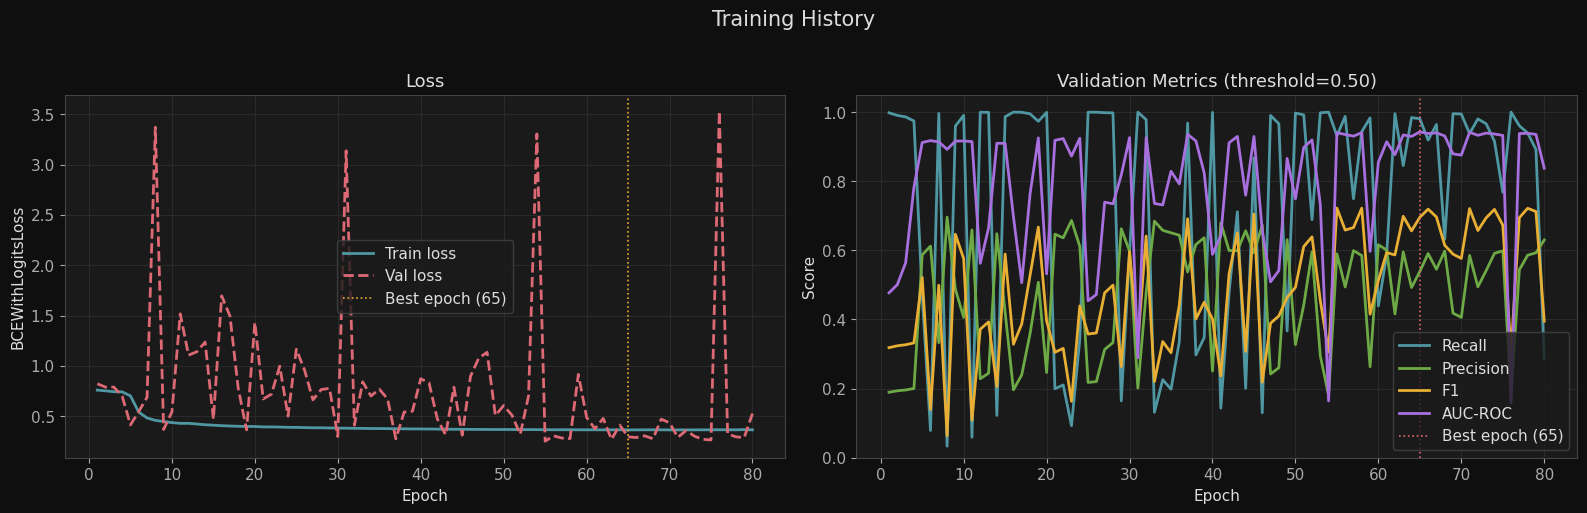

✅ Saved → /home/USER/PROJECT_ROOT/figures/2026-04-10 Third Iteration/inception_ResNet/training_history.png


In [34]:
# ── Consistent plot style for all Section 7 figures ──────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#1a1a1a',
    'axes.edgecolor':    '#444444',
    'axes.labelcolor':   '#dddddd',
    'xtick.color':       '#aaaaaa',
    'ytick.color':       '#aaaaaa',
    'text.color':        '#dddddd',
    'grid.color':        '#2a2a2a',
    'grid.linewidth':    0.8,
    'legend.facecolor':  '#1a1a1a',
    'legend.edgecolor':  '#444444',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})

ACCENT  = '#4f98a3'   # teal — primary metric lines
ACCENT2 = '#dd6974'   # red  — val loss / complementary metric

# ── Load history from CSV (correct even in resumed sessions) ──────────────────
history_df  = pd.read_csv(HISTORY_PATH)
best_ep_idx = history_df['val_auc_roc'].idxmax()
best_ep     = history_df.loc[best_ep_idx, 'epoch']
epochs_axis = history_df['epoch'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Training History', fontsize=15, y=1.02)

# ── Left: Loss curves ─────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_axis, history_df['train_loss'], color=ACCENT,  lw=2, label='Train loss')
ax.plot(epochs_axis, history_df['val_loss'],   color=ACCENT2, lw=2, label='Val loss',
        linestyle='--')
ax.axvline(best_ep, color='#e8af34', lw=1.2, linestyle=':', label=f'Best epoch ({best_ep})')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCEWithLogitsLoss')
ax.set_title('Loss')
ax.legend()
ax.grid(True)

# ── Right: Val metrics ────────────────────────────────────────────────────────
ax = axes[1]
metric_cols   = ['val_recall', 'val_precision', 'val_f1', 'val_auc_roc']
metric_labels = ['Recall', 'Precision', 'F1', 'AUC-ROC']
metric_colors = ['#4f98a3', '#6daa45', '#e8af34', '#a86fdf']

for col, label, color in zip(metric_cols, metric_labels, metric_colors):
    ax.plot(epochs_axis, history_df[col], color=color, lw=2, label=label)

ax.axvline(best_ep, color='#dd6974', lw=1.2, linestyle=':', label=f'Best epoch ({best_ep})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('Validation Metrics (threshold=0.50)')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True)

plt.tight_layout()
out_path = FIGURESDIR / 'training_history.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Saved → {out_path}")
log.info(f"Figure saved: {out_path}")

### Confusion Matrix

Shown in two forms side by side:
  - Left  — absolute counts (TP, FP, FN, TN). Useful for understanding the
           raw scale of errors given the dataset size.
  - Right — row-normalised percentages (what fraction of each true class was
           predicted correctly). Normalising by row removes the effect of
           class imbalance and lets you read recall and specificity directly
           off the diagonal.

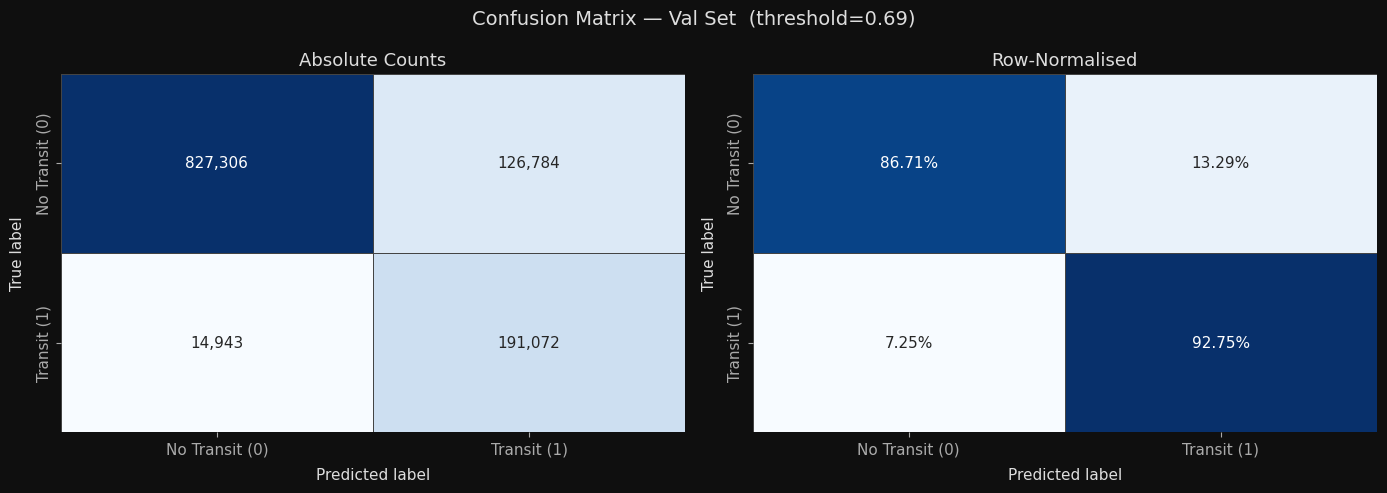

✅ Saved → /home/USER/PROJECT_ROOT/figures/2026-04-10 Third Iteration/inception_ResNet/confusion_matrix.png


In [35]:
cm       = confusion_matrix(val_labels_final, y_pred_val)
cm_norm  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
labels   = ['No Transit (0)', 'Transit (1)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Confusion Matrix — Val Set  (threshold={BEST_THRESHOLD:.2f})', fontsize=14)

for ax, data, fmt, title in zip(
    axes,
    [cm,      cm_norm],
    [',.0f',  '.2%'],
    ['Absolute Counts', 'Row-Normalised'],
):
    sns.heatmap(
        data,
        ax          = ax,
        annot       = True,
        fmt         = fmt,
        cmap        = 'Blues',
        xticklabels = labels,
        yticklabels = labels,
        linewidths  = 0.5,
        linecolor   = '#444',
        cbar        = False,
    )
    ax.set_xlabel('Predicted label', labelpad=8)
    ax.set_ylabel('True label',      labelpad=8)
    ax.set_title(title)

plt.tight_layout()
out_path = FIGURESDIR / 'confusion_matrix.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Saved → {out_path}")
log.info(f"Figure saved: {out_path}")

### Precision–Recall Curve

The PR curve is more informative than the ROC curve for imbalanced datasets.
A random classifier on a dataset with 18% positives achieves an AP score of
~0.18 regardless of threshold — this is the no-skill baseline marked as a
dashed horizontal line. Any model worth deploying should be well above it.

The operating point at BEST_THRESHOLD is marked with a star so you can see
exactly where on the curve the selected threshold sits.

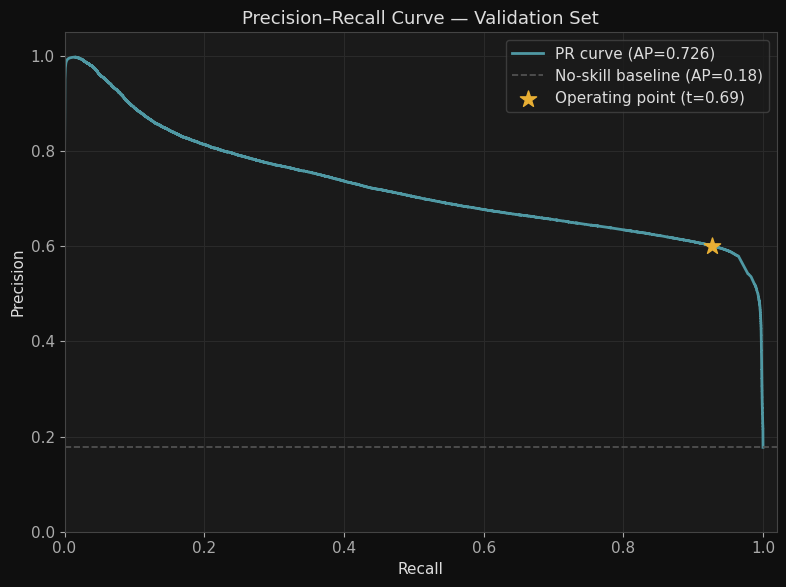

✅ Saved → /home/USER/PROJECT_ROOT/figures/2026-04-10 Third Iteration/inception_ResNet/pr_curve.png
   Average Precision (AP): 0.7263
   No-skill baseline     : 0.1776


In [36]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    val_labels_final, expit(val_logits_final)
)
ap_score = average_precision_score(val_labels_final, expit(val_logits_final))

# ── Operating point on the curve ──────────────────────────────────────────────
op_precision = final_val_metrics['precision']
op_recall    = final_val_metrics['recall']

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(recall_curve, precision_curve,
        color=ACCENT, lw=2, label=f'PR curve (AP={ap_score:.3f})')

# No-skill baseline
no_skill = val_labels_final.mean()
ax.axhline(no_skill, color='#555555', lw=1.2, linestyle='--',
           label=f'No-skill baseline (AP={no_skill:.2f})')

# Operating point
ax.scatter(op_recall, op_precision, color='#e8af34', s=150, zorder=5,
           marker='*', label=f'Operating point (t={BEST_THRESHOLD:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curve — Validation Set')
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right')
ax.grid(True)

plt.tight_layout()
out_path = FIGURESDIR / 'pr_curve.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Saved → {out_path}")
print(f"   Average Precision (AP): {ap_score:.4f}")
print(f"   No-skill baseline     : {no_skill:.4f}")
log.info(f"PR curve saved. AP={ap_score:.4f} | no-skill={no_skill:.4f}")

### ROC Curve

Plots the true positive rate (recall) vs false positive rate at every threshold. The diagonal dashed line represents a random classifier (AUC=0.5).

While the PR curve is the primary diagnostic for this imbalanced problem, the ROC curve is included because AUC-ROC is the most widely reported metric in the exoplanet classification literature (AstroNet, ExoMiner, etc.), making it easy to compare this model against published baselines.

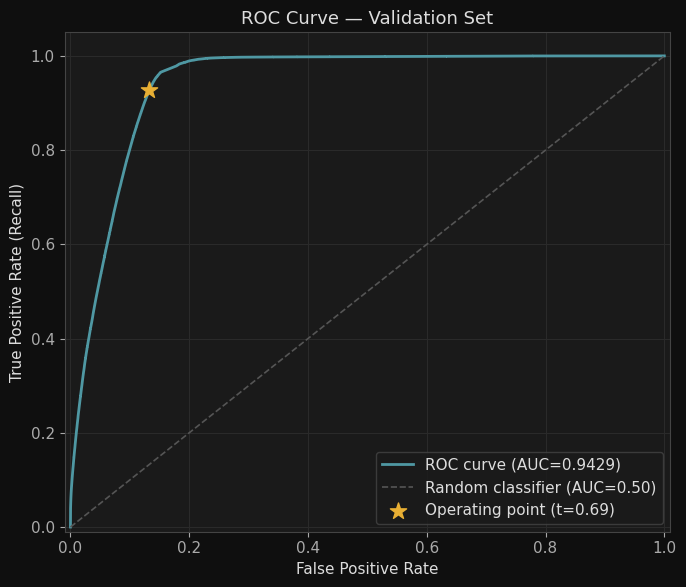

✅ Saved → /home/USER/PROJECT_ROOT/figures/2026-04-10 Third Iteration/inception_ResNet/roc_curve.png
   AUC-ROC : 0.9429


In [37]:
fpr, tpr, roc_thresholds = roc_curve(val_labels_final, expit(val_logits_final))
roc_auc = roc_auc_score(val_labels_final, expit(val_logits_final))

# ── Operating point: find closest threshold in roc_thresholds ─────────────────
op_idx = int(np.argmin(np.abs(roc_thresholds - BEST_THRESHOLD)))
op_fpr = fpr[op_idx]
op_tpr = tpr[op_idx]

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr,
        color=ACCENT, lw=2, label=f'ROC curve (AUC={roc_auc:.4f})')
ax.plot([0, 1], [0, 1],
        color='#555555', lw=1.2, linestyle='--', label='Random classifier (AUC=0.50)')
ax.scatter(op_fpr, op_tpr, color='#e8af34', s=150, zorder=5,
           marker='*', label=f'Operating point (t={BEST_THRESHOLD:.2f})')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Validation Set')
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.05)
ax.legend(loc='lower right')
ax.grid(True)

plt.tight_layout()
out_path = FIGURESDIR / 'roc_curve.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Saved → {out_path}")
print(f"   AUC-ROC : {roc_auc:.4f}")
log.info(f"ROC curve saved. AUC={roc_auc:.4f}")

## 8. Test Set Evaluation

⚠️  RUN THIS SECTION EXACTLY ONCE.

The test set is the held-out final arbiter of model performance. Running it multiple times and adjusting anything based on what you see constitutes test set leakage — the reported numbers would no longer be trustworthy estimates of real-world performance.

The correct sequence is:
  1. All training decisions are complete (architecture, pos_weight, etc.)
  2. BEST_THRESHOLD is locked (selected on val set in Section 6)
  3. Best checkpoint is loaded (done in Section 5.3)
  4. Run this section once
  5. Report these numbers

BEST_THRESHOLD is loaded from the checkpoint file, not from the in-memory variable, to guarantee consistency even if this section is run in a fresh session after training.

### Load Best Checkpoint and Threshold

Loads the model weights and BEST_THRESHOLD from the checkpoint file. This cell is written to be runnable in a completely fresh Colab session — it does not depend on any in-memory variables from training. The only prerequisites are: Drive is mounted (Section 1.3), model class is defined (Section 3), and the checkpoint file exists on Drive.

In [38]:
# ── Load checkpoint into model ────────────────────────────────────────────────
assert eval_ckpt_path.exists(), (
    f"Checkpoint not found: {eval_ckpt_path}\n"
    f"Ensure Drive is mounted and training has completed."
)

ckpt = torch.load(eval_ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# ── Retrieve threshold saved in Section 6.4 ───────────────────────────────────
assert 'best_threshold' in ckpt, (
    "Checkpoint does not contain 'best_threshold'. "
    "Did Section 6.4 complete successfully?"
)
TEST_THRESHOLD = ckpt['best_threshold']

print(f"✅ Checkpoint loaded from: {eval_ckpt_path.name}")
print(f"   Saved at epoch    : {ckpt.get('epoch', 'unknown')}")
print(f"   TEST_THRESHOLD    : {TEST_THRESHOLD:.2f}")
print(f"   Val metrics at save:")
for k, v in ckpt.get('val_metrics_final', {}).items():
    if k != 'threshold':
        print(f"     {k:<12}: {v:.4f}")

log.info(f"Test eval: checkpoint loaded from epoch={ckpt.get('epoch')} | "
         f"TEST_THRESHOLD={TEST_THRESHOLD:.2f}")

✅ Checkpoint loaded from: best_auc_inception_resnet.pt
   Saved at epoch    : 65
   TEST_THRESHOLD    : 0.69
   Val metrics at save:
     precision   : 0.6011
     recall      : 0.9275
     f1          : 0.7295
     auc_roc     : 0.9429
     accuracy    : 0.8778


### Test Set Inference

One full pass over the test DataLoader under torch.no_grad().
Identical to eval_one_epoch — reused directly, no new code.
The test set was never seen during training or threshold selection.

In [39]:
print("Running test set inference...\n")

test_loss, test_logits, test_labels = eval_one_epoch(
    model, test_loader, criterion,
    desc = 'Test inference',
    total_steps = test_steps_per_epoch,
)

print(f"  Test loss        : {test_loss:.5f}")
print(f"  Logits shape     : {test_logits.shape}")
print(f"  Positive labels  : {int(test_labels.sum()):,}  "
      f"({100*test_labels.mean():.1f}%)")

log.info(f"Test inference complete. loss={test_loss:.5f}")

Running test set inference...



Test inference:   0%|                                                              | 0/2268 [00:00<?, ?batch/s…

  Test loss        : 0.41603
  Logits shape     : (1161306,)
  Positive labels  : 211,050  (18.2%)


### Final Test Metrics

The definitive performance numbers for this model. These are computed at TEST_THRESHOLD (selected entirely on the val set — no information from the test set was used to derive it).

These are the numbers to record in a paper, report, or README.

In [40]:
test_metrics = compute_metrics(test_labels, test_logits, threshold=TEST_THRESHOLD)

y_prob_test = expit(test_logits)
y_pred_test = (y_prob_test >= TEST_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(test_labels, y_pred_test).ravel()

print(f"\n{'═'*60}")
print(f"  FINAL TEST SET RESULTS")
print(f"  Threshold : {TEST_THRESHOLD:.2f}")
print(f"{'═'*60}")
print(f"  Precision : {test_metrics['precision']:.4f}")
print(f"  Recall    : {test_metrics['recall']:.4f}")
print(f"  F1        : {test_metrics['f1']:.4f}")
print(f"  AUC-ROC   : {test_metrics['auc_roc']:.4f}")
print(f"  Accuracy  : {test_metrics['accuracy']:.4f}")
print(f"{'─'*60}")
print(f"  TP: {tp:>8,}   FP: {fp:>8,}")
print(f"  FN: {fn:>8,}   TN: {tn:>8,}")
print(f"{'─'*60}")
print(f"  Missed transits (FN) : {fn:,}  ({100*fn/(tp+fn):.1f}% of all positives)")
print(f"  False alarms   (FP)  : {fp:,}  ({100*fp/(fp+tn):.1f}% of all negatives)")
print(f"{'═'*60}")

log.info(f"FINAL TEST RESULTS @ t={TEST_THRESHOLD:.2f}: "
         f"TP={tp} FP={fp} FN={fn} TN={tn} | "
         f"{format_metrics(test_metrics)}")


════════════════════════════════════════════════════════════
  FINAL TEST SET RESULTS
  Threshold : 0.69
════════════════════════════════════════════════════════════
  Precision : 0.6095
  Recall    : 0.9324
  F1        : 0.7371
  AUC-ROC   : 0.9415
  Accuracy  : 0.8791
────────────────────────────────────────────────────────────
  TP:  196,785   FP:  126,093
  FN:   14,265   TN:  824,163
────────────────────────────────────────────────────────────
  Missed transits (FN) : 14,265  (6.8% of all positives)
  False alarms   (FP)  : 126,093  (13.3% of all negatives)
════════════════════════════════════════════════════════════


### Test Set Visualisations

Mirrors the four validation plots from Section 7, now on the test set. Saved to FIGURESDIR with a `test_` prefix so they don't overwrite the validation figures.

  - Confusion matrix (absolute + row-normalised)
  - Precision–Recall curve with operating point
  - ROC curve with operating point

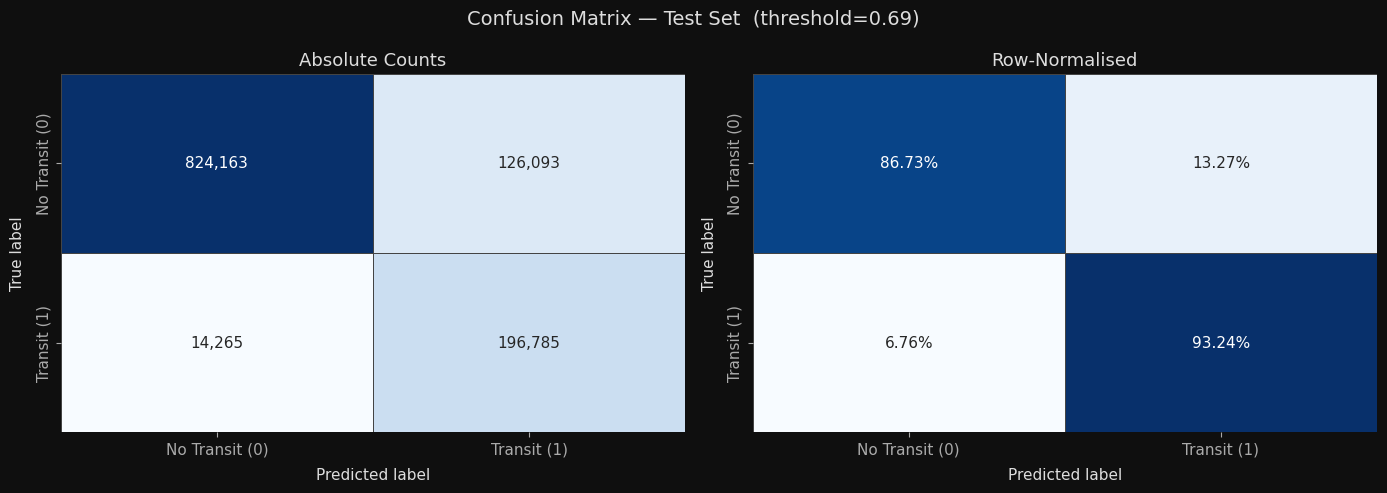

✅ Saved → /home/USER/PROJECT_ROOT/figures/2026-04-10 Third Iteration/inception_ResNet/test_confusion_matrix.png


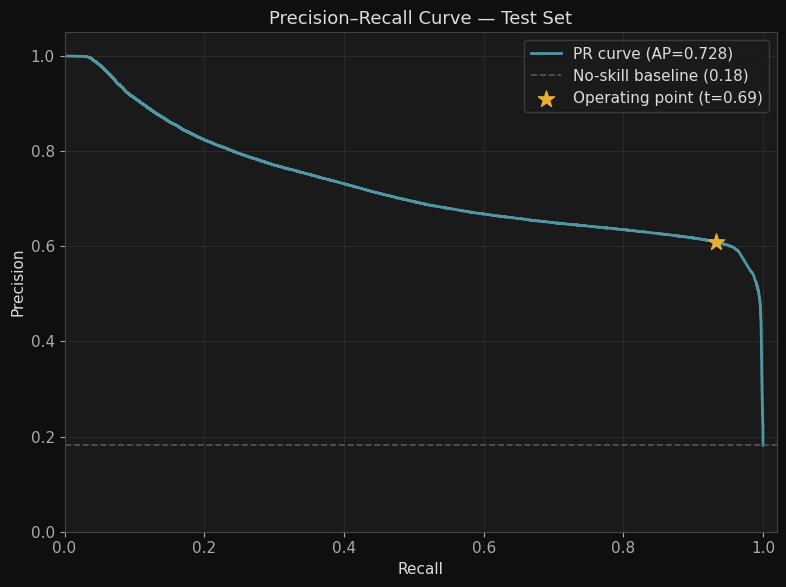

✅ Saved → /home/USER/PROJECT_ROOT/figures/2026-04-10 Third Iteration/inception_ResNet/test_pr_curve.png


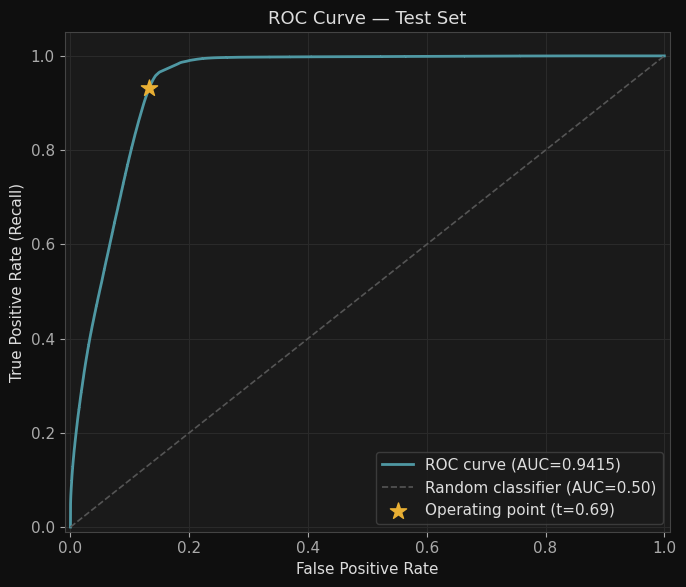

✅ Saved → /home/USER/PROJECT_ROOT/figures/2026-04-10 Third Iteration/inception_ResNet/test_roc_curve.png


In [41]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm_test      = confusion_matrix(test_labels, y_pred_test)
cm_test_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Confusion Matrix — Test Set  (threshold={TEST_THRESHOLD:.2f})', fontsize=14)

for ax, data, fmt, title in zip(
    axes,
    [cm_test,      cm_test_norm],
    [',.0f',       '.2%'],
    ['Absolute Counts', 'Row-Normalised'],
):
    sns.heatmap(
        data,
        ax          = ax,
        annot       = True,
        fmt         = fmt,
        cmap        = 'Blues',
        xticklabels = labels,
        yticklabels = labels,
        linewidths  = 0.5,
        linecolor   = '#444',
        cbar        = False,
    )
    ax.set_xlabel('Predicted label', labelpad=8)
    ax.set_ylabel('True label',      labelpad=8)
    ax.set_title(title)

plt.tight_layout()
out_path = FIGURESDIR / 'test_confusion_matrix.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Saved → {out_path}")

# ── PR curve ──────────────────────────────────────────────────────────────────
prec_c, rec_c, _ = precision_recall_curve(test_labels, y_prob_test)
ap_test           = average_precision_score(test_labels, y_prob_test)
no_skill_test     = test_labels.mean()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec_c, prec_c, color=ACCENT, lw=2, label=f'PR curve (AP={ap_test:.3f})')
ax.axhline(no_skill_test, color='#555555', lw=1.2, linestyle='--',
           label=f'No-skill baseline ({no_skill_test:.2f})')
ax.scatter(test_metrics['recall'], test_metrics['precision'],
           color='#e8af34', s=150, zorder=5, marker='*',
           label=f'Operating point (t={TEST_THRESHOLD:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curve — Test Set')
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right')
ax.grid(True)
plt.tight_layout()
out_path = FIGURESDIR / 'test_pr_curve.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Saved → {out_path}")

# ── ROC curve ─────────────────────────────────────────────────────────────────
fpr_t, tpr_t, roc_thresh_t = roc_curve(test_labels, y_prob_test)
roc_auc_test = roc_auc_score(test_labels, y_prob_test)
op_idx_t = int(np.argmin(np.abs(roc_thresh_t - TEST_THRESHOLD)))

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_t, tpr_t, color=ACCENT, lw=2, label=f'ROC curve (AUC={roc_auc_test:.4f})')
ax.plot([0, 1], [0, 1], color='#555555', lw=1.2, linestyle='--',
        label='Random classifier (AUC=0.50)')
ax.scatter(fpr_t[op_idx_t], tpr_t[op_idx_t],
           color='#e8af34', s=150, zorder=5, marker='*',
           label=f'Operating point (t={TEST_THRESHOLD:.2f})')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Test Set')
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.05)
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
out_path = FIGURESDIR / 'test_roc_curve.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Saved → {out_path}")

log.info(f"Test figures saved. AP={ap_test:.4f} AUC={roc_auc_test:.4f}")

### Save Final Results

Writes the complete test metrics to a JSON file on Drive alongside the checkpoint. This gives you a single self-contained record of what this model achieved without needing to re-run the notebook.

In [42]:
final_results = {
    'checkpoint':       str(BEST_CKPT_PATH),
    'best_epoch':       int(ckpt.get('epoch', -1)),
    'test_threshold':   float(TEST_THRESHOLD),
    'test_loss':        float(round(test_loss, 5)),
    'test_precision':   float(round(test_metrics['precision'], 4)),
    'test_recall':      float(round(test_metrics['recall'], 4)),
    'test_f1':          float(round(test_metrics['f1'], 4)),
    'test_auc_roc':     float(round(test_metrics['auc_roc'], 4)),
    'test_accuracy':    float(round(test_metrics['accuracy'], 4)),
    'test_ap':          float(round(ap_test, 4)),
    'test_tp':          int(tp),
    'test_fp':          int(fp),
    'test_fn':          int(fn),
    'test_tn':          int(tn),
    'val_metrics':      ckpt.get('val_metrics_final', {}),
    'train_cfg':        TRAIN_CFG,
    'timestamp':        datetime.now().isoformat(),
}

results_path = MODELSDIR / 'final_test_results.json'
with open(results_path, 'w') as f:
    json.dump(final_results, f, indent=2)

print(f"✅ Final results saved → {results_path}")
print(f"\n{'═'*60}")
print(f"  Notebook complete.")
print(f"{'═'*60}")
print(f"  Checkpoint  : {BEST_CKPT_PATH}")
print(f"  Results     : {results_path}")
print(f"  History CSV : {HISTORY_PATH}")
print(f"  Figures     : {FIGURESDIR}")
print(f"{'═'*60}")

log.info(f"Pipeline complete. Results saved to {results_path}")

✅ Final results saved → /home/USER/PROJECT_ROOT/models/2026-04-10 Third Iteration/inception_ResNet/final_test_results.json

════════════════════════════════════════════════════════════
  Notebook complete.
════════════════════════════════════════════════════════════
  Checkpoint  : /home/USER/PROJECT_ROOT/models/2026-04-10 Third Iteration/inception_ResNet/best_auc_inception_resnet.pt
  Results     : /home/USER/PROJECT_ROOT/models/2026-04-10 Third Iteration/inception_ResNet/final_test_results.json
  History CSV : /home/USER/PROJECT_ROOT/models/2026-04-10 Third Iteration/inception_ResNet/inception_resnet_training_history.csv
  Figures     : /home/USER/PROJECT_ROOT/figures/2026-04-10 Third Iteration/inception_ResNet
════════════════════════════════════════════════════════════
